## Setup

In [20]:
# GPU CHECK ────────────────────────────────────────────────────────────
%env CUDA_VISIBLE_DEVICES=0

import xgboost as xgb, os, json
import optuna, pandas as pd
import matplotlib.pyplot as plt
import shap, numpy as np
import dice_ml

from dice_ml import Dice
from scipy import sparse as sp
from cfnow import find_tabular

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.datasets import fetch_openml
from sklearn.metrics import (
    accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score, 
    average_precision_score, log_loss, 
    mean_squared_error, mean_absolute_error, r2_score,
    precision_recall_curve
)

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
)
from sklearn.linear_model import ElasticNet, HuberRegressor, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401
from sklearn.ensemble import HistGradientBoostingRegressor
from catboost import CatBoostRegressor, Pool

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

env: CUDA_VISIBLE_DEVICES=0


## Data Collection

In [21]:
# ── 0 · DATA (Dataset Selector) ───────────────────────────────────────
from sklearn.datasets import fetch_openml, load_breast_cancer
import pandas as pd

DATASET_NAME = "bank_marketing"

if DATASET_NAME == "adult_xgb":
    X, y = fetch_openml("adult", version=2, as_frame=True, return_X_y=True)
    y = (y == ">50K")  # binary labels

elif DATASET_NAME == "breast_cancer":
    data = load_breast_cancer(as_frame=True)
    X = data.data
    y = data.target

elif DATASET_NAME == "bank_marketing":
    X, y = fetch_openml("bank-marketing", version=1, as_frame=True, return_X_y=True)
    y = (y == "1")

elif DATASET_NAME == "phishing":
    X, y = fetch_openml("PhishingWebsites", version=1, as_frame=True, return_X_y=True)
    y = (y.astype(int) == 1)
    
else:
    raise ValueError(f"Unknown DATASET_NAME={DATASET_NAME!r}")


In [22]:
# detect categorical / numerical columns
cat = X.select_dtypes(include=["category", "object"]).columns
num = X.select_dtypes(include=["int", "float"]).columns

enc = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
        ("num", "passthrough",                         num),
    ]
)

# 60% train, 20% validation, 20% test
X_tr, X_temp, y_tr, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=0, stratify=y
)
X_va, X_te, y_va, y_te = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=0, stratify=y_temp
)

X_tr_enc = enc.fit_transform(X_tr)
X_va_enc = enc.transform(X_va)
X_te_enc = enc.transform(X_te)

# Ensure CSR for robust slicing/stacking
if sp.issparse(X_tr_enc): X_tr_enc = X_tr_enc.tocsr()
if sp.issparse(X_va_enc): X_va_enc = X_va_enc.tocsr()
if sp.issparse(X_te_enc): X_te_enc = X_te_enc.tocsr()

In [23]:
# Helper to simulate missing values for features
def inject_missing(X_df, num_cols, cat_cols, rate, rng):
    """Return a copy of X_df with NaNs injected at `rate` into both num & cat columns."""
    if rate <= 0:
        return X_df.copy()
    Xm = X_df.copy()
    n = len(Xm)
    # numeric
    for c in num_cols:
        m = rng.random(n) < rate
        if m.all():  # avoid all-NaN column
            m[rng.integers(0, n)] = False
        Xm.loc[m, c] = np.nan
    # categorical
    for c in cat_cols:
        m = rng.random(n) < rate
        if m.all():
            m[rng.integers(0, n)] = False
        Xm.loc[m, c] = np.nan
    return Xm

In [24]:
def objective(trial):
    # ----- XGBoost hyperparameters (widened) -----
    params = {
        "booster": trial.suggest_categorical("booster", ["gbtree", "dart"]),
        "n_estimators":  trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth":     trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 0.5, log=True),

        "min_child_weight": trial.suggest_float("min_child_weight", 0.1, 100.0, log=True),
        "gamma":            trial.suggest_float("gamma", 0.0, 10.0),
        "lambda":           trial.suggest_float("lambda", 1e-4, 100.0, log=True),
        "alpha":            trial.suggest_float("alpha", 1e-4, 100.0, log=True),
        "subsample":        trial.suggest_float("subsample", 0.2, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 1.0),

        "tree_method": "gpu_hist",
        "grow_policy": trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"]),
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 10),
        "predictor":  "gpu_predictor",
        "objective":  "binary:logistic",
        "eval_metric": "error",
        "verbosity": 0,
        "gpu_id": 0,
        "random_state": 0,
    }
    if params["booster"] == "dart":
        params.update(
            rate_drop      = trial.suggest_float("rate_drop", 0.0, 0.5),
            skip_drop      = trial.suggest_float("skip_drop", 0.0, 0.9),
            sample_type    = trial.suggest_categorical("sample_type", ["uniform", "weighted"]),
            normalize_type = trial.suggest_categorical("normalize_type", ["tree", "forest"]),
        )

    # ----- Soft knobs -----
    rng_rows = np.random.default_rng(trial.number)

    # 1) Stratified row subsample of TRAIN
    sample_rows = trial.suggest_float("params_sample_rows", 0.5, 1.0)
    y_tr_np = np.asarray(y_tr, dtype=int)
    idx_pos = np.where(y_tr_np == 1)[0]
    idx_neg = np.where(y_tr_np == 0)[0]
    n_pos   = max(1, int(len(idx_pos) * sample_rows))
    n_neg   = max(1, int(len(idx_neg) * sample_rows))
    sub_pos = rng_rows.choice(idx_pos, size=n_pos, replace=False)
    sub_neg = rng_rows.choice(idx_neg, size=n_neg, replace=False)
    tr_sel  = np.concatenate([sub_pos, sub_neg])
    rng_rows.shuffle(tr_sel)
    ytr_sub = y_tr_np[tr_sel].astype(int)

    # 2) TRAIN-only missingness
    u = trial.suggest_float("params_missing_rate", 0.0, 0.10)
    _grid = np.array([0.08, 0.1, 0.12, 
                      0.14, 0.16, 0.18, 0.2, 0.22, 0.24, 
                      0.26, 0.28, 0.3])
    missing_rate = float(_grid[np.argmin(np.abs(_grid - u))])
    rng_mask = np.random.default_rng((trial.number, int(round(missing_rate * 100))))
    X_tr_masked = inject_missing(X.iloc[tr_sel], num, cat, missing_rate, rng_mask)
    X_va_masked = X_va
    X_te_masked = X_te

    # 3) Preprocess
    preproc = ColumnTransformer([
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]), cat),
        ("num", "passthrough", num),
    ])
    params["missing"] = np.nan

    Xtr_enc = preproc.fit_transform(X_tr_masked)
    Xva_enc = preproc.transform(X_va_masked)
    Xte_enc = preproc.transform(X_te_masked)
    if sp.issparse(Xtr_enc): Xtr_enc = Xtr_enc.tocsr()
    if sp.issparse(Xva_enc): Xva_enc = Xva_enc.tocsr()
    if sp.issparse(Xte_enc): Xte_enc = Xte_enc.tocsr()

    # 4) Resampling vs SPW
    resampling_strategy = trial.suggest_categorical("params_resampling", ["none", "undersample", "oversample"])
    if resampling_strategy != "none":
        params["scale_pos_weight"] = 1.0
    else:
        params["scale_pos_weight"] = trial.suggest_float("params_scale_pos_weight", 0.5, 5.0, log=True)

    ysub = np.asarray(ytr_sub, dtype=int)
    pos_idx = np.where(ysub == 1)[0]
    neg_idx = np.where(ysub == 0)[0]

    def _stack_rows(XA, XB):
        if sp.issparse(XA) or sp.issparse(XB):
            XA = XA.tocsr() if sp.issparse(XA) else sp.csr_matrix(XA)
            XB = XB.tocsr() if sp.issparse(XB) else sp.csr_matrix(XB)
            return sp.vstack([XA, XB], format="csr")
        return np.vstack([XA, XB])

    if resampling_strategy == "undersample" and len(pos_idx) and len(neg_idx):
        n_min = min(len(pos_idx), len(neg_idx))
        pos_keep = rng_rows.choice(pos_idx, size=n_min, replace=False)
        neg_keep = rng_rows.choice(neg_idx, size=n_min, replace=False)
        keep = np.concatenate([pos_keep, neg_keep])
        Xtr_enc = Xtr_enc[keep]
        ytr_sub = ytr_sub[keep].astype(int)
        ysub    = ytr_sub
        pos_idx = np.where(ysub == 1)[0]; neg_idx = np.where(ysub == 0)[0]
    elif resampling_strategy == "oversample" and len(pos_idx) and len(neg_idx):
        n_max = max(len(pos_idx), len(neg_idx))
        pos_add = rng_rows.choice(pos_idx, size=n_max - len(pos_idx), replace=True) if len(pos_idx) < n_max else np.array([], dtype=int)
        neg_add = rng_rows.choice(neg_idx, size=n_max - len(neg_idx), replace=True) if len(neg_idx) < n_max else np.array([], dtype=int)
        add_idx = np.concatenate([pos_add, neg_add])
        if add_idx.size:
            Xtr_enc = _stack_rows(Xtr_enc, Xtr_enc[add_idx])
            ytr_sub = np.concatenate([ytr_sub, ytr_sub[add_idx]]).astype(int)
            ysub    = ytr_sub

    # 5) Feature fraction
    feature_fraction = trial.suggest_float("params_feature_fraction", 0.5, 1.0)
    n_features = Xtr_enc.shape[1]
    k_features = max(1, int(n_features * feature_fraction))
    feat_idx   = np.sort(rng_rows.choice(np.arange(n_features), size=k_features, replace=False))
    Xtr_sub, Xva_sub, Xte_sub = Xtr_enc[:, feat_idx], Xva_enc[:, feat_idx], Xte_enc[:, feat_idx]

    # 6) Semi-supervised
    labeled_ratio = trial.suggest_float("params_labeled_ratio", 0.2, 0.9)
    if (len(pos_idx) > 0 and len(neg_idx) > 0) and (labeled_ratio < 1.0):
        keep_pos = max(1, int(round(len(pos_idx) * labeled_ratio))); keep_pos = min(keep_pos, len(pos_idx))
        keep_neg = max(1, int(round(len(neg_idx) * labeled_ratio))); keep_neg = min(keep_neg, len(neg_idx))
        labeled_keep = np.concatenate([
            rng_rows.choice(pos_idx, size=keep_pos, replace=False),
            rng_rows.choice(neg_idx, size=keep_neg, replace=False)
        ])
        y_semi = np.full(ytr_sub.shape, -1, dtype=int)
        y_semi[labeled_keep] = ytr_sub[labeled_keep]
        if (y_semi == -1).sum() == 0:
            clf = xgb.XGBClassifier(**params).fit(Xtr_sub, ytr_sub)
        else:
            from sklearn.semi_supervised import SelfTrainingClassifier
            clf = SelfTrainingClassifier(
                estimator=xgb.XGBClassifier(**params),
                threshold=trial.suggest_float("params_selftrain_threshold", 0.6, 0.95),
                max_iter=trial.suggest_int("params_selftrain_max_iter", 5, 12),
                verbose=False
            ).fit(Xtr_sub, y_semi)
    else:
        clf = xgb.XGBClassifier(**params).fit(Xtr_sub, ytr_sub)

    #decision_thr = trial.suggest_float("user_attrs_decision_threshold", 0.2, 0.8)
    decision_thr = 0.5
    y_va_int = np.asarray(y_va, dtype=int)
    y_te_int = np.asarray(y_te, dtype=int)

    proba_va = clf.predict_proba(Xva_sub)[:, 1]
    proba_te = clf.predict_proba(Xte_sub)[:, 1]
    yhat_va  = (proba_va >= decision_thr).astype(int)
    yhat_te  = (proba_te >= decision_thr).astype(int)

    f1_val = f1_score(y_va_int, yhat_va, zero_division=0)

    # ── Log metrics ─────────────────
    trial.set_user_attr("f1_val", f1_val)
    trial.set_user_attr("f1_test", f1_score(y_te_int, yhat_te, zero_division=0))
    trial.set_user_attr("acc_val",  accuracy_score(y_va_int, yhat_va))
    trial.set_user_attr("acc_test", accuracy_score(y_te_int, yhat_te))
    trial.set_user_attr("prec_val", precision_score(y_va_int, yhat_va, zero_division=0))
    trial.set_user_attr("prec_test", precision_score(y_te_int, yhat_te, zero_division=0))
    trial.set_user_attr("rec_val",  recall_score(y_va_int, yhat_va, zero_division=0))
    trial.set_user_attr("rec_test", recall_score(y_te_int, yhat_te, zero_division=0))
    trial.set_user_attr("roc_auc_val", roc_auc_score(y_va_int, proba_va))
    trial.set_user_attr("roc_auc_test", roc_auc_score(y_te_int, proba_te))
    trial.set_user_attr("pr_auc_val", average_precision_score(y_va_int, proba_va))
    trial.set_user_attr("pr_auc_test", average_precision_score(y_te_int, proba_te))

    # log applied soft knobs
    trial.set_user_attr("sample_rows", sample_rows)
    trial.set_user_attr("resampling_strategy", resampling_strategy)
    trial.set_user_attr("feature_fraction", feature_fraction)
    trial.set_user_attr("missing_rate", missing_rate)
    trial.set_user_attr("labeled_ratio", float(labeled_ratio))
    trial.set_user_attr("user_attrs_decision_threshold", float(decision_thr))

    return f1_val


In [25]:
TARGET_TRIALS = 3000

# Let ~10–15% be pure random, then switch to TPE guidance
sampler = optuna.samplers.RandomSampler(
    # n_startup_trials=6000,
    # n_ei_candidates=64,
    # consider_prior=True,
    # multivariate=True,
    # group=True,
    seed=0,
)

study = optuna.create_study(
    direction="maximize",
    study_name=f"{DATASET_NAME}_xgb_tpe_with_soft_params",
    storage=f"sqlite:///data/{DATASET_NAME}_xgb_with_soft_params.db",
    load_if_exists=True,
    sampler=sampler,
)

already_done = len(study.trials)
remaining   = max(TARGET_TRIALS - already_done, 0)

if remaining:
    print(f"Running {remaining} additional trials (have {already_done}, need {TARGET_TRIALS})")
    study.optimize(objective, n_trials=remaining, gc_after_trial=True)
else:
    print(f"Target of {TARGET_TRIALS} trials already reached – nothing to do")

print("Best F1:", study.best_value)
print("Best params:", study.best_params)

[I 2026-01-16 13:23:23,500] Using an existing study with name 'bank_marketing_xgb_tpe_with_soft_params' instead of creating a new one.


Target of 3000 trials already reached – nothing to do
Best F1: 0.9384515901475516
Best params: {'booster': 'gbtree', 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.10032842339930786, 'min_child_weight': 0.12770447638438479, 'gamma': 6.793863502088709, 'lambda': 0.00043207959070056516, 'alpha': 0.005736512828719903, 'subsample': 0.4089877918739851, 'colsample_bytree': 0.9181196140003236, 'grow_policy': 'depthwise', 'max_delta_step': 0, 'params_sample_rows': 0.8838818771031632, 'params_missing_rate': 0.029154692473934832, 'params_resampling': 'none', 'params_scale_pos_weight': 2.245363189418946, 'params_feature_fraction': 0.8207285709057708, 'params_labeled_ratio': 0.2682064285193332, 'params_selftrain_threshold': 0.771005934954592, 'params_selftrain_max_iter': 12}


In [26]:
# --- Save trials dataframe to CSV ---
df = study.trials_dataframe()
CSV = f"data/{DATASET_NAME}_trials_with_soft_params.csv"
df.to_csv(CSV, index=False)
print(f"Saved {len(df)} trials to {CSV}")

Saved 7000 trials to data/bank_marketing_trials_with_soft_params.csv


## Exploring collected data

In [27]:
df_bs_c = pd.read_csv(f"data/{DATASET_NAME}_trials_with_soft_params.csv", index_col=0)
df = df_bs_c.dropna(subset=["value"])
print(f"Rows: {len(df_bs_c)}  |  Columns: {df_bs_c.shape[1]}")
display(df.iloc[:3, :42].T)

Rows: 7000  |  Columns: 47


number,2,3,4
value,0.93786,0.93786,0.618596
datetime_start,2025-11-28 15:32:37.194916,2025-11-28 15:33:39.861448,2025-11-28 15:33:40.810141
datetime_complete,2025-11-28 15:33:39.718216,2025-11-28 15:33:40.677972,2025-11-28 15:33:53.429798
duration,0 days 00:01:02.523300,0 days 00:00:00.816524,0 days 00:00:12.619657
params_alpha,60.530821,0.503042,0.000459
params_booster,dart,gbtree,dart
params_colsample_bytree,0.83338,0.745456,0.310546
params_gamma,4.375872,6.176355,2.444256
params_grow_policy,lossguide,lossguide,lossguide
params_lambda,22.420124,0.470516,0.000899


In [28]:
# --- 1.3 Quick preview ---
# A) Wide preview: first 5 rows with ALL columns (no truncation)
display(df.iloc[:5])

display(df.iloc[:10, :51].T)

# Optional: show *all* column names as a numbered list
for i, c in enumerate(df.columns, 1):
    print(f"{i:>3}. {c}")

,value,datetime_start,datetime_complete,duration,params_alpha,params_booster,params_colsample_bytree,params_gamma,params_grow_policy,params_lambda,params_learning_rate,params_max_delta_step,params_max_depth,params_min_child_weight,params_n_estimators,params_normalize_type,params_params_feature_fraction,params_params_labeled_ratio,params_params_missing_rate,params_params_resampling,params_params_sample_rows,params_params_scale_pos_weight,params_params_selftrain_max_iter,params_params_selftrain_threshold,params_rate_drop,params_sample_type,params_skip_drop,params_subsample,user_attrs_acc_test,user_attrs_acc_val,user_attrs_f1_test,user_attrs_f1_val,user_attrs_feature_fraction,user_attrs_labeled_ratio,user_attrs_missing_rate,user_attrs_pr_auc_test,user_attrs_pr_auc_val,user_attrs_prec_test,user_attrs_prec_val,user_attrs_rec_test,user_attrs_rec_val,user_attrs_resampling_strategy,user_attrs_roc_auc_test,user_attrs_roc_auc_val,user_attrs_sample_rows,user_attrs_user_attrs_decision_threshold,state
number,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,0.937860,2025-11-28 15:32:37.194916,2025-11-28 15:33:39.718216,0 days 00:01:02.523300,60.530821,dart,0.833380,4.375872,lossguide,22.420124,0.003691,10,8,8.663280,700,forest,0.819961,0.300347,0.079916,undersample,0.989309,NaN,9.0,0.930634,0.035518,weighted,0.078416,0.506753,0.883003,0.882990,0.937867,0.937860,0.819961,0.300347,0.08,0.883003,0.882990,0.883003,0.882990,1.000000,1.000000,undersample,0.500000,0.500000,0.989309,0.5,COMPLETE
3,0.937860,2025-11-28 15:33:39.861448,2025-11-28 15:33:40.677972,0 days 00:00:00.816524,0.503042,gbtree,0.745456,6.176355,lossguide,0.470516,0.012665,7,7,0.113860,800,NaN,0.681855,0.599138,0.066677,none,0.530113,1.033709,12.0,0.753511,NaN,NaN,NaN,0.954998,0.883003,0.882990,0.937867,0.937860,0.681855,0.599138,0.08,0.891532,0.888484,0.883003,0.882990,1.000000,1.000000,none,0.510434,0.503062,0.530113,0.5,COMPLETE
4,0.618596,2025-11-28 15:33:40.810141,2025-11-28 15:33:53.429798,0 days 00:00:12.619657,0.000459,dart,0.310546,2.444256,lossguide,0.000899,0.000865,9,9,2.505719,300,forest,0.648070,0.283109,0.073926,undersample,0.802423,NaN,8.0,0.711294,0.048551,weighted,0.754150,0.725064,0.496185,0.492811,0.623222,0.618596,0.648070,0.283109,0.08,0.914439,0.913139,0.917458,0.920545,0.471885,0.465807,undersample,0.622186,0.617688,0.802423,0.5,COMPLETE
5,0.937860,2025-11-28 15:33:53.562133,2025-11-28 15:34:40.227909,0 days 00:00:46.665776,0.008155,dart,0.305438,5.759465,depthwise,37.651058,0.008619,2,5,0.191347,700,tree,0.786126,0.356157,0.096219,oversample,0.867597,NaN,8.0,0.933462,0.293256,uniform,0.018097,0.733928,0.883003,0.882990,0.937867,0.937860,0.786126,0.356157,0.08,0.862413,0.858446,0.883003,0.882990,1.000000,1.000000,oversample,0.385213,0.368309,0.867597,0.5,COMPLETE
6,0.786108,2025-11-28 15:34:40.367927,2025-11-28 15:34:40.943784,0 days 00:00:00.575857,1.429518,gbtree,0.601060,5.812729,depthwise,19.516960,0.002929,4,11,43.985506,400,NaN,0.809008,0.500138,0.001919,undersample,0.803197,NaN,7.0,0.647416,NaN,NaN,NaN,0.780203,0.679199,0.678500,0.786644,0.786108,0.809008,0.500138,0.00,0.934759,0.936640,0.952958,0.952738,0.669756,0.669088,undersample,0.716710,0.718403,0.803197,0.5,COMPLETE


number,2,3,4,5,6,7,8,9,10,11
value,0.93786,0.93786,0.618596,0.93786,0.786108,0.93786,0.658694,0.735147,0.93786,0.93786
datetime_start,2025-11-28 15:32:37.194916,2025-11-28 15:33:39.861448,2025-11-28 15:33:40.810141,2025-11-28 15:33:53.562133,2025-11-28 15:34:40.367927,2025-11-28 15:34:41.081386,2025-11-28 15:35:43.708612,2025-11-28 15:35:44.375341,2025-11-28 15:36:00.982527,2025-11-28 15:36:59.689124
datetime_complete,2025-11-28 15:33:39.718216,2025-11-28 15:33:40.677972,2025-11-28 15:33:53.429798,2025-11-28 15:34:40.227909,2025-11-28 15:34:40.943784,2025-11-28 15:35:43.556555,2025-11-28 15:35:44.212055,2025-11-28 15:36:00.841315,2025-11-28 15:36:59.548389,2025-11-28 15:37:10.656520
duration,0 days 00:01:02.523300,0 days 00:00:00.816524,0 days 00:00:12.619657,0 days 00:00:46.665776,0 days 00:00:00.575857,0 days 00:01:02.475169,0 days 00:00:00.503443,0 days 00:00:16.465974,0 days 00:00:58.565862,0 days 00:00:10.967396
params_alpha,60.530821,0.503042,0.000459,0.008155,1.429518,0.041228,0.001585,0.08765,0.0013,3.104429
params_booster,dart,gbtree,dart,dart,gbtree,dart,gbtree,dart,dart,dart
params_colsample_bytree,0.83338,0.745456,0.310546,0.305438,0.60106,0.844955,0.834958,0.403485,0.749991,0.266738
params_gamma,4.375872,6.176355,2.444256,5.759465,5.812729,8.965466,5.210366,9.443724,2.73542,9.404319
params_grow_policy,lossguide,lossguide,lossguide,depthwise,depthwise,depthwise,lossguide,lossguide,lossguide,lossguide
params_lambda,22.420124,0.470516,0.000899,37.651058,19.51696,0.016046,0.000212,2.737189,6.141593,3.907973


  1. value
  2. datetime_start
  3. datetime_complete
  4. duration
  5. params_alpha
  6. params_booster
  7. params_colsample_bytree
  8. params_gamma
  9. params_grow_policy
 10. params_lambda
 11. params_learning_rate
 12. params_max_delta_step
 13. params_max_depth
 14. params_min_child_weight
 15. params_n_estimators
 16. params_normalize_type
 17. params_params_feature_fraction
 18. params_params_labeled_ratio
 19. params_params_missing_rate
 20. params_params_resampling
 21. params_params_sample_rows
 22. params_params_scale_pos_weight
 23. params_params_selftrain_max_iter
 24. params_params_selftrain_threshold
 25. params_rate_drop
 26. params_sample_type
 27. params_skip_drop
 28. params_subsample
 29. user_attrs_acc_test
 30. user_attrs_acc_val
 31. user_attrs_f1_test
 32. user_attrs_f1_val
 33. user_attrs_feature_fraction
 34. user_attrs_labeled_ratio
 35. user_attrs_missing_rate
 36. user_attrs_pr_auc_test
 37. user_attrs_pr_auc_val
 38. user_attrs_prec_test
 39. user_attr

In [29]:
# --- 1.2 Column groups ---
col_groups = {
    "params":        [c for c in df.columns if c.startswith("params_")],
    "user_attrs":    [c for c in df.columns if c.startswith("user_attrs_")],
    "optuna_core":   [c for c in ["number", "value", "state", "datetime_start", "datetime_complete", "duration"] if c in df.columns],
    "other":         []
}
used = set(sum(col_groups.values(), []))
col_groups["other"] = [c for c in df.columns if c not in used]

for k in ["optuna_core", "params", "user_attrs", "other"]:
    if col_groups[k]:
        print(f"\n[{k}] ({len(col_groups[k])}):")
        preview = ", ".join(col_groups[k][:12])
        print(preview + (" ..." if len(col_groups[k]) > 12 else ""))


[optuna_core] (5):
value, state, datetime_start, datetime_complete, duration

[params] (24):
params_alpha, params_booster, params_colsample_bytree, params_gamma, params_grow_policy, params_lambda, params_learning_rate, params_max_delta_step, params_max_depth, params_min_child_weight, params_n_estimators, params_normalize_type ...

[user_attrs] (18):
user_attrs_acc_test, user_attrs_acc_val, user_attrs_f1_test, user_attrs_f1_val, user_attrs_feature_fraction, user_attrs_labeled_ratio, user_attrs_missing_rate, user_attrs_pr_auc_test, user_attrs_pr_auc_val, user_attrs_prec_test, user_attrs_prec_val, user_attrs_rec_test ...


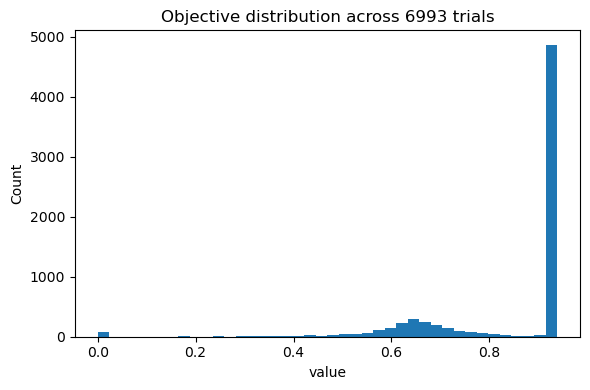

In [30]:
# --- 1.5 Objective distribution (value = F1_val) ---
if "value" in df.columns:
    plt.figure(figsize=(6,4))
    plt.hist(df["value"].dropna(), bins=40)
    plt.xlabel("value")
    plt.ylabel("Count")
    plt.title(f"Objective distribution across {df['value'].notna().sum()} trials")
    plt.tight_layout()
    plt.show()

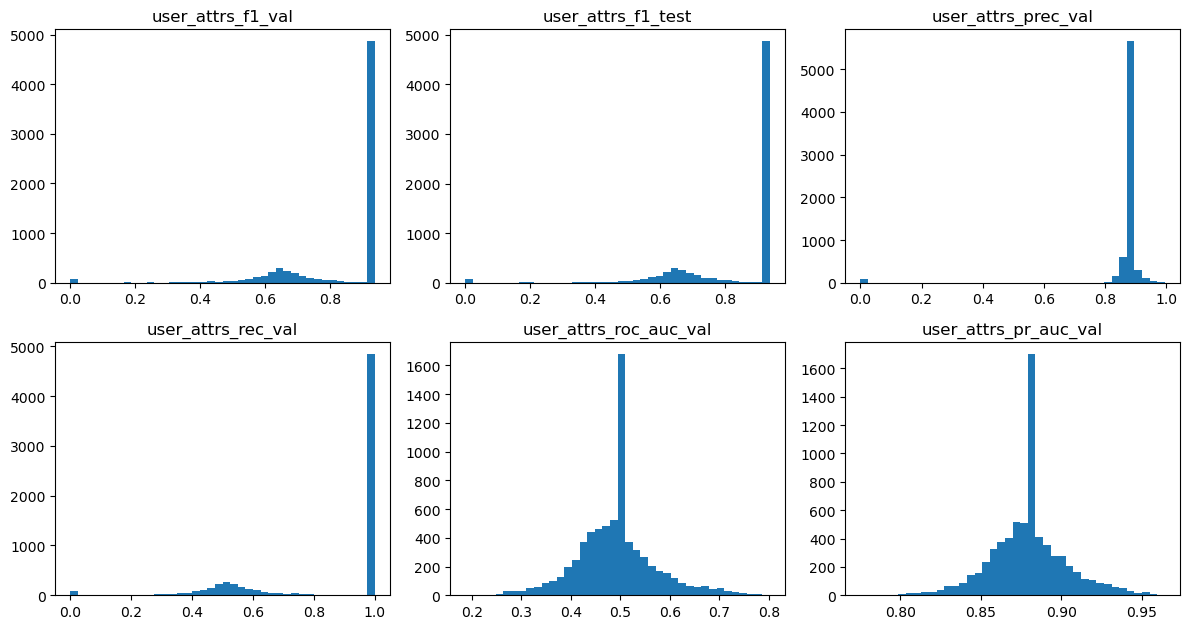

In [31]:
# --- 1.6 Key metric histograms ---
key_metrics = [m for m in [
    "user_attrs_f1_val", "user_attrs_f1_test",
    "user_attrs_prec_val", "user_attrs_rec_val",
    "user_attrs_roc_auc_val", "user_attrs_pr_auc_val",
    "user_attrs_decision_threshold"
] if m in df.columns]

if key_metrics:
    n = len(key_metrics)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(4*ncols, 3.2*nrows))
    for i, m in enumerate(key_metrics, 1):
        plt.subplot(nrows, ncols, i)
        plt.hist(pd.to_numeric(df[m], errors="coerce").dropna(), bins=40)
        plt.title(m)
        plt.tight_layout()
    plt.show()


In [32]:
# --- 1.7 Categorical knobs summary (value counts) ---
for col in ["params_booster", "params_grow_policy", "params_params_resampling"]:
    if col in df.columns:
        print(f"\nValue counts — {col}:")
        print(df[col].value_counts(dropna=False))


Value counts — params_booster:
gbtree    3518
dart      3475
Name: params_booster, dtype: int64

Value counts — params_grow_policy:
depthwise    3532
lossguide    3461
Name: params_grow_policy, dtype: int64

Value counts — params_params_resampling:
undersample    2401
none           2384
oversample     2208
Name: params_params_resampling, dtype: int64


In [33]:
# --- 1.9 Best & worst trials by objective ---
if "value" in df.columns and df["value"].notna().any():
    best_idx = df["value"].idxmax()
    worst_idx = df["value"].idxmin()
    best, worst = df.loc[best_idx], df.loc[worst_idx]
    print("\n=== BEST trial ===")
    display(best.filter(like="param_").to_frame().T)
    print(f"value (objective): {best['value']:.4f}")
    print("\n=== WORST trial ===")
    display(worst.filter(like="param_").to_frame().T)
    print(f"value (objective): {worst['value']:.4f}")


=== BEST trial ===


""
6466


value (objective): 0.9385

=== WORST trial ===


""
83


value (objective): 0.0000


## Cleaning dataset

In [34]:
# ================== 1. CLEAN TRIAL LOG + DERIVE SOFT DESCRIPTORS ==================

# keep only successful trials
df_clean = df[df["state"] != "FAIL"].copy()

print(f"Original rows: {len(df)}")
print(f"After removing FAIL rows: {len(df_clean)}")

# ------------------------------------------------------------------
# 1.1 Canonicalise duplicated soft knobs
# ------------------------------------------------------------------

# Decision threshold: create a single canonical column `user_attrs_decision_threshold`
if "user_attrs_user_attrs_decision_threshold" in df_clean.columns:
    df_clean["user_attrs_decision_threshold"] = pd.to_numeric(
        df_clean["user_attrs_user_attrs_decision_threshold"], errors="coerce"
    )
elif "params_user_attrs_decision_threshold" in df_clean.columns:
    df_clean["user_attrs_decision_threshold"] = pd.to_numeric(
        df_clean["params_user_attrs_decision_threshold"], errors="coerce"
    )

df_clean["user_attrs_decision_threshold"] = df_clean["user_attrs_decision_threshold"].fillna(0.5)

# ------------------------------------------------------------------
# 1.2 Drop columns we no longer need (IDs, timestamps, and raw duplicates)
# ------------------------------------------------------------------
drop_cols = [
    "number",
    "datetime_start",
    "datetime_complete",
    "duration",
    "state",
    "source",

    # raw / duplicated knobs – we keep the user_attrs_* versions
    "params_params_decision_threshold",
    "params_params_feature_fraction",
    "params_params_sample_rows",
    "params_params_resampling",
    "params_user_attrs_decision_threshold",
    "user_attrs_user_attrs_decision_threshold",
    "params_params_labeled_ratio",
    "params_params_missing_rate",
]

df_clean = df_clean.drop(columns=drop_cols, errors="ignore")


Original rows: 6993
After removing FAIL rows: 6993


## Feature engineering (soft params)

### 1) Risk preference

In [35]:
# ------------------------------------------------------------------
# 1.3 Feature-engineered soft descriptors
# ------------------------------------------------------------------

# --- Risk preference ----------------------------------------------------
# Decision threshold (already canonical)
thr = df_clean["user_attrs_decision_threshold"].astype(float)

# Scale_pos_weight (still comes from params_params_* at this stage)
spw = pd.to_numeric(
    df_clean.get("params_params_scale_pos_weight", np.nan),
    errors="coerce"
).fillna(1.0)

# Resampling strategy (canonical user_attrs_*)
res = df_clean.get("user_attrs_resampling_strategy", "none") \
               .fillna("none") \
               .astype(str)

# Risk score
risk_score = (-(thr - 0.5)) \
             + np.log(spw) \
             + res.map({"oversample": 1, "undersample": 0.5}).fillna(0)

def label_risk(s, tol=0.2):
    if pd.isna(s):
        return np.nan
    if abs(s) < tol:
        return "balanced"
    return "recall_pref" if s > 0 else "precision_pref"

df_clean["soft_risk_preference"] = risk_score.map(label_risk)


### 2) Decision speed (model complexity)

In [36]:
# --- Decision speed (complexity tertiles) -------------------------------
comp = df_clean["params_max_depth"] * df_clean["params_n_estimators"]
q1, q2 = comp.quantile([0.33, 0.66])

def label_speed(x):
    if pd.isna(x):
        return np.nan
    if x < q1:
        return "fast"
    if x < q2:
        return "balanced"
    return "slow"

df_clean["soft_decision_speed"] = comp.map(label_speed)


### 3) Dataset size

In [37]:
# --- Effective training rows --------------------------------------------
N_train = len(X_tr)   # from your original 60/20/20 split
frac = df_clean.get("user_attrs_sample_rows")  # canonical fraction
df_clean["soft_train_rows"] = (frac * N_train).round().astype("Int64")


In [38]:
# --- Quick preview ------------------------------------------------------
display(df_clean.iloc[:5])
first_k = 48
display(df_clean.iloc[:5, :first_k].T)

for i, c in enumerate(df_clean.columns, 1):
    print(f"{i:>3}. {c}")

,value,params_alpha,params_booster,params_colsample_bytree,params_gamma,params_grow_policy,params_lambda,params_learning_rate,params_max_delta_step,params_max_depth,params_min_child_weight,params_n_estimators,params_normalize_type,params_params_scale_pos_weight,params_params_selftrain_max_iter,params_params_selftrain_threshold,params_rate_drop,params_sample_type,params_skip_drop,params_subsample,user_attrs_acc_test,user_attrs_acc_val,user_attrs_f1_test,user_attrs_f1_val,user_attrs_feature_fraction,user_attrs_labeled_ratio,user_attrs_missing_rate,user_attrs_pr_auc_test,user_attrs_pr_auc_val,user_attrs_prec_test,user_attrs_prec_val,user_attrs_rec_test,user_attrs_rec_val,user_attrs_resampling_strategy,user_attrs_roc_auc_test,user_attrs_roc_auc_val,user_attrs_sample_rows,user_attrs_decision_threshold,soft_risk_preference,soft_decision_speed,soft_train_rows
number,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,0.937860,60.530821,dart,0.833380,4.375872,lossguide,22.420124,0.003691,10,8,8.663280,700,forest,NaN,9.0,0.930634,0.035518,weighted,0.078416,0.506753,0.883003,0.882990,0.937867,0.937860,0.819961,0.300347,0.08,0.883003,0.882990,0.883003,0.882990,1.000000,1.000000,undersample,0.500000,0.500000,0.989309,0.5,recall_pref,slow,26836
3,0.937860,0.503042,gbtree,0.745456,6.176355,lossguide,0.470516,0.012665,7,7,0.113860,800,NaN,1.033709,12.0,0.753511,NaN,NaN,NaN,0.954998,0.883003,0.882990,0.937867,0.937860,0.681855,0.599138,0.08,0.891532,0.888484,0.883003,0.882990,1.000000,1.000000,none,0.510434,0.503062,0.530113,0.5,balanced,slow,14380
4,0.618596,0.000459,dart,0.310546,2.444256,lossguide,0.000899,0.000865,9,9,2.505719,300,forest,NaN,8.0,0.711294,0.048551,weighted,0.754150,0.725064,0.496185,0.492811,0.623222,0.618596,0.648070,0.283109,0.08,0.914439,0.913139,0.917458,0.920545,0.471885,0.465807,undersample,0.622186,0.617688,0.802423,0.5,recall_pref,balanced,21767
5,0.937860,0.008155,dart,0.305438,5.759465,depthwise,37.651058,0.008619,2,5,0.191347,700,tree,NaN,8.0,0.933462,0.293256,uniform,0.018097,0.733928,0.883003,0.882990,0.937867,0.937860,0.786126,0.356157,0.08,0.862413,0.858446,0.883003,0.882990,1.000000,1.000000,oversample,0.385213,0.368309,0.867597,0.5,recall_pref,balanced,23534
6,0.786108,1.429518,gbtree,0.601060,5.812729,depthwise,19.516960,0.002929,4,11,43.985506,400,NaN,NaN,7.0,0.647416,NaN,NaN,NaN,0.780203,0.679199,0.678500,0.786644,0.786108,0.809008,0.500138,0.00,0.934759,0.936640,0.952958,0.952738,0.669756,0.669088,undersample,0.716710,0.718403,0.803197,0.5,recall_pref,balanced,21788


number,2,3,4,5,6
value,0.93786,0.93786,0.618596,0.93786,0.786108
params_alpha,60.530821,0.503042,0.000459,0.008155,1.429518
params_booster,dart,gbtree,dart,dart,gbtree
params_colsample_bytree,0.83338,0.745456,0.310546,0.305438,0.60106
params_gamma,4.375872,6.176355,2.444256,5.759465,5.812729
params_grow_policy,lossguide,lossguide,lossguide,depthwise,depthwise
params_lambda,22.420124,0.470516,0.000899,37.651058,19.51696
params_learning_rate,0.003691,0.012665,0.000865,0.008619,0.002929
params_max_delta_step,10,7,9,2,4
params_max_depth,8,7,9,5,11


  1. value
  2. params_alpha
  3. params_booster
  4. params_colsample_bytree
  5. params_gamma
  6. params_grow_policy
  7. params_lambda
  8. params_learning_rate
  9. params_max_delta_step
 10. params_max_depth
 11. params_min_child_weight
 12. params_n_estimators
 13. params_normalize_type
 14. params_params_scale_pos_weight
 15. params_params_selftrain_max_iter
 16. params_params_selftrain_threshold
 17. params_rate_drop
 18. params_sample_type
 19. params_skip_drop
 20. params_subsample
 21. user_attrs_acc_test
 22. user_attrs_acc_val
 23. user_attrs_f1_test
 24. user_attrs_f1_val
 25. user_attrs_feature_fraction
 26. user_attrs_labeled_ratio
 27. user_attrs_missing_rate
 28. user_attrs_pr_auc_test
 29. user_attrs_pr_auc_val
 30. user_attrs_prec_test
 31. user_attrs_prec_val
 32. user_attrs_rec_test
 33. user_attrs_rec_val
 34. user_attrs_resampling_strategy
 35. user_attrs_roc_auc_test
 36. user_attrs_roc_auc_val
 37. user_attrs_sample_rows
 38. user_attrs_decision_threshold
 39

In [39]:
csv_path = f"data/{DATASET_NAME}_ready_for_surrogates.csv"
df_clean.to_csv(csv_path, index=False)
print(f"\nSaved clean dataset to: {csv_path}  | shape={df_clean.shape}")


Saved clean dataset to: data/bank_marketing_ready_for_surrogates.csv  | shape=(6993, 41)


## Training surrogate models

In [40]:
# ================== 2. BUILD SURROGATE DATASET ==================

df_sur = pd.read_csv(f"data/{DATASET_NAME}_ready_for_surrogates.csv", low_memory=False)
print(f"Loaded dataset from CSV  | shape={df_sur.shape}")

# Target
y_sur = df_sur["value"].rename("f1")

# Features (normalise params_params_* -> params_ for remaining params cols)
desired_features_raw = [
    # --- Hard model hyperparameters -------------------------------------
    "params_alpha","params_booster","params_colsample_bytree","params_gamma",
    "params_grow_policy","params_lambda","params_learning_rate","params_max_delta_step",
    "params_max_depth","params_min_child_weight","params_n_estimators","params_normalize_type",
    "params_params_scale_pos_weight","params_rate_drop","params_sample_type","params_skip_drop",
    "params_subsample",

    # --- Canonical soft knobs (user_attrs_*) ----------------------------
    "user_attrs_decision_threshold",
    "user_attrs_feature_fraction",
    "user_attrs_resampling_strategy",
    "user_attrs_sample_rows",
    "user_attrs_labeled_ratio",
    "user_attrs_missing_rate",

    # --- Semi-supervised hyperparameters (still under params_*) --------
    "params_params_selftrain_max_iter",
    "params_params_selftrain_threshold",

    # --- Engineered soft descriptors -----------------------------------
    "soft_risk_preference",
    "soft_decision_speed",
    "soft_train_rows",
]

# Replace 'params_params_' prefix by 'params_' to match df_sur columns
desired_features = [c.replace("params_params_", "params_") for c in desired_features_raw]
df_sur = df_sur.rename(columns=lambda c: c.replace("params_params_", "params_"))

present = [c for c in desired_features if c in df_sur.columns]
missing = [c for c in desired_features if c not in df_sur.columns]
if missing:
    print("WARNING: missing requested features (skipped):", missing)

X_sur = df_sur[present].copy()

# --- DART conditionals --------------------------------------------------
if "params_booster" in X_sur.columns:
    dart_float = [c for c in ["params_rate_drop","params_skip_drop"] if c in X_sur.columns]
    dart_cat   = [c for c in ["params_sample_type","params_normalize_type"] if c in X_sur.columns]
    mask_not_dart = X_sur["params_booster"].astype(str).ne("dart")
    for c in dart_float:
        X_sur.loc[mask_not_dart, c] = 0.0
    for c in dart_cat:
        X_sur.loc[mask_not_dart, c] = "NA"

# --- Treat specific NaNs as "use default" -------------------------------
# Defaults: scale_pos_weight=1.0, decision_threshold=0.5
if "params_scale_pos_weight" in X_sur.columns:
    X_sur["params_scale_pos_weight"] = pd.to_numeric(
        X_sur["params_scale_pos_weight"], errors="coerce"
    ).fillna(1.0)

if "user_attrs_decision_threshold" in X_sur.columns:
    X_sur["user_attrs_decision_threshold"] = pd.to_numeric(
        X_sur["user_attrs_decision_threshold"], errors="coerce"
    ).fillna(0.5)

# --- Make categoricals strings -----------------------------------------
for c in [
    "params_booster","params_grow_policy","params_sample_type","params_normalize_type",
    "user_attrs_resampling_strategy","soft_risk_preference","soft_decision_speed"
]:
    if c in X_sur.columns:
        X_sur[c] = X_sur[c].astype("string")

# --- Column types -------------------------------------------------------
cat_cols = X_sur.select_dtypes(include=["object","category","string"]).columns.tolist()
num_cols = X_sur.columns.difference(cat_cols).tolist()

# --- Preprocessor -------------------------------------------------------
preproc = ColumnTransformer([
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="NA")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),
    ("num", SimpleImputer(strategy="median"), num_cols),
])

print("\nSelected features:", len(X_sur.columns))
print("Categorical:", len(cat_cols), "| Numeric:", len(num_cols))
print("\nmissing counts:")
print(X_sur.isna().sum().sort_values(ascending=False).head())

# --- Train / validation split ------------------------------------------
X_tr_sur, X_va_sur, y_tr_sur, y_va_sur = train_test_split(
    X_sur, y_sur, test_size=0.2, random_state=0
)

Loaded dataset from CSV  | shape=(6993, 41)

Selected features: 28
Categorical: 7 | Numeric: 21

missing counts:
params_alpha                  0
params_booster                0
soft_decision_speed           0
soft_risk_preference          0
params_selftrain_threshold    0
dtype: int64


In [41]:
# -----------------------------------------------------------------------------
# 1) Helpers
# -----------------------------------------------------------------------------
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def make_ohe_dense():
    """Version-safe dense OHE (sklearn>=1.2 uses sparse_output)."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def evaluate_pipe(name, pipe, X_tr=X_tr_sur, y_tr=y_tr_sur, X_va=X_va_sur, y_va=y_va_sur):
    pipe.fit(X_tr, y_tr)
    yhat = pipe.predict(X_va)
    res = {
        "name": name,
        "rmse": rmse(y_va, yhat),
        "mae":  mean_absolute_error(y_va, yhat),
        "r2":   r2_score(y_va, yhat),
        "predict_fn": lambda X: pipe.predict(X),
    }
    print(f"[{name}] RMSE={res['rmse']:.4f} | MAE={res['mae']:.4f} | R²={res['r2']:.4f}")
    return res


In [42]:
# -----------------------------------------------------------------------------
# 2) Shared preprocessors (define ONCE)
# -----------------------------------------------------------------------------
# NaN-safe trees (sklearn trees don’t accept NaNs in numerics)
preproc_tree = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),    # OHE handles NaN category
    ("num", SimpleImputer(strategy="median"),        num_cols),   # impute numeric NaNs
])

# Dense-required models (HGBDT, KNN, SVR)
preproc_dense = ColumnTransformer([
    ("cat", make_ohe_dense(), cat_cols),
    ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
])

# Linear models (impute + scale)
cat_lin = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])
num_lin = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc",  StandardScaler()),
])
lin_preproc = ColumnTransformer([
    ("cat", cat_lin, cat_cols),
    ("num", num_lin, num_cols),
])

In [43]:
# -----------------------------------------------------------------------------
# 3) Models dictionary
# -----------------------------------------------------------------------------
models = {
    # Boosters (use your sparse OHE preproc)
    "LightGBM": Pipeline([
        ("pre", preproc),
        ("lgb", LGBMRegressor(
            n_estimators=1500, learning_rate=0.03,
            num_leaves=63, subsample=0.8, colsample_bytree=0.8,
            reg_lambda=5.0, random_state=0
        ))
    ]),
    "XGBoost": Pipeline([
        ("pre", preproc),
        ("xgb", XGBRegressor(
            n_estimators=1500, learning_rate=0.03, max_depth=8,
            subsample=0.8, colsample_bytree=0.8,
            reg_lambda=5.0, reg_alpha=0.0,
            tree_method="hist", random_state=0, n_jobs=-1
        ))
    ]),

    # Sklearn tree family (NaN-safe preproc_tree)
    "ExtraTrees": Pipeline([
        ("pre", preproc_tree),
        ("et", ExtraTreesRegressor(
            n_estimators=1200, max_features=None, min_samples_leaf=1,
            random_state=0, n_jobs=-1
        ))
    ]),
    "RandomForest": Pipeline([
        ("pre", preproc_tree),
        ("rf", RandomForestRegressor(
            n_estimators=800, max_depth=None, min_samples_leaf=1,
            random_state=0, n_jobs=-1
        ))
    ]),
    "GBRegressor": Pipeline([
        ("pre", preproc_tree),
        ("gbr", GradientBoostingRegressor(
            n_estimators=800, learning_rate=0.05, max_depth=3, subsample=0.8,
            random_state=0
        ))
    ]),
    "AdaBoost": Pipeline([
        ("pre", preproc_tree),
        ("ada", AdaBoostRegressor(
            estimator=DecisionTreeRegressor(max_depth=6, random_state=0),
            n_estimators=400, learning_rate=0.05, random_state=0
        ))
    ]),
    "DecisionTree": Pipeline([
        ("pre", preproc_tree),
        ("dt", DecisionTreeRegressor(max_depth=None, random_state=0))
    ]),

    # Dense-required
    "HistGBDT": Pipeline([
        ("pre", preproc_dense),
        ("hgb", HistGradientBoostingRegressor(
            max_depth=None, max_bins=255, learning_rate=0.06,
            min_samples_leaf=20, l2_regularization=1.0,
            early_stopping=True, random_state=0
        ))
    ]),
    "KNN": Pipeline([
        ("pre", Pipeline([("ct", preproc_dense), ("sc", StandardScaler(with_mean=False))])),
        ("knn", KNeighborsRegressor(n_neighbors=15, weights="distance", p=2, n_jobs=-1))
    ]),
    "SVR": Pipeline([
        ("pre", Pipeline([("ct", preproc_dense), ("sc", StandardScaler(with_mean=False))])),
        ("svr", SVR(C=3.0, epsilon=0.02, gamma="scale"))
    ]),

    # Linear baselines
    "ElasticNet": Pipeline([
        ("pre", lin_preproc),
        ("lr",  ElasticNet(alpha=0.01, l1_ratio=0.2, random_state=0, max_iter=10000))
    ]),
    "HuberReg": Pipeline([
        ("pre", lin_preproc),
        ("huber", HuberRegressor(alpha=1e-4, epsilon=1.35, max_iter=2000))
    ]),
    "BayesianRidge": Pipeline([
        ("pre", lin_preproc),
        ("br", BayesianRidge())
    ]),
}

In [44]:
# -----------------------------------------------------------------------------
# 4) CatBoost (native categoricals) — evaluated separately
# -----------------------------------------------------------------------------
results = []
cat_idx = [X_sur.columns.get_loc(c) for c in cat_cols]
cb_params = dict(
    depth=8, learning_rate=0.05, l2_leaf_reg=6.0,
    iterations=2000, loss_function="RMSE", random_seed=0,
    od_type="Iter", od_wait=100, verbose=False
)
cb_eval = CatBoostRegressor(**cb_params)
cb_eval.fit(Pool(X_tr_sur, y_tr_sur, cat_features=cat_idx),
            eval_set=Pool(X_va_sur, y_va_sur, cat_features=cat_idx),
            use_best_model=True, verbose=False)
yhat_cb = cb_eval.predict(X_va_sur)
cb_res = {
    "name": "CatBoost",
    "rmse": rmse(y_va_sur, yhat_cb),
    "mae":  mean_absolute_error(y_va_sur, yhat_cb),
    "r2":   r2_score(y_va_sur, yhat_cb),
    "predict_fn": lambda X: cb_eval.predict(X),
}
print(f"[CatBoost] RMSE={cb_res['rmse']:.4f} | MAE={cb_res['mae']:.4f} | R²={cb_res['r2']:.4f}")
results.append(cb_res)

[CatBoost] RMSE=0.0960 | MAE=0.0366 | R²=0.7012


In [45]:
# -----------------------------------------------------------------------------
# 5) Batch evaluate remaining models
# -----------------------------------------------------------------------------
for name, pipe in models.items():
    results.append(evaluate_pipe(name, pipe))

# -----------------------------------------------------------------------------
# 6) Leaderboard + simple top-3 weighted ensemble (weights ∝ 1/RMSE²)
# -----------------------------------------------------------------------------
summary = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
print("\n=== Surrogate leaderboard (val) ===")
print(summary[["name", "rmse", "mae", "r2"]])

topk = 3
top = summary.head(topk)
weights = (1.0 / (top["rmse"] ** 2)).to_numpy()
weights = weights / weights.sum()

name_to_pred = {r["name"]: r["predict_fn"] for r in results}
preds = [name_to_pred[n](X_va_sur) for n in top["name"]]
yhat_ens = np.tensordot(weights, np.vstack(preds), axes=1)

ens_metrics = {
    "rmse": rmse(y_va_sur, yhat_ens),
    "mae":  mean_absolute_error(y_va_sur, yhat_ens),
    "r2":   r2_score(y_va_sur, yhat_ens),
}
print(f"\n[Ensemble top-{topk}] RMSE={ens_metrics['rmse']:.4f} | "
      f"MAE={ens_metrics['mae']:.4f} | R²={ens_metrics['r2']:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001041 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3909
[LightGBM] [Info] Number of data points in the train set: 5594, number of used features: 39
[LightGBM] [Info] Start training from score 0.838761
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

/home/jovyan/.conda/envs/env_hpo_xai/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] RMSE=0.1058 | MAE=0.0412 | R²=0.6371
[XGBoost] RMSE=0.1061 | MAE=0.0392 | R²=0.6351
[ExtraTrees] RMSE=0.1067 | MAE=0.0376 | R²=0.6311
[RandomForest] RMSE=0.1014 | MAE=0.0366 | R²=0.6669
[GBRegressor] RMSE=0.0985 | MAE=0.0422 | R²=0.6856
[AdaBoost] RMSE=0.1044 | MAE=0.0390 | R²=0.6468
[DecisionTree] RMSE=0.1250 | MAE=0.0442 | R²=0.4941
[HistGBDT] RMSE=0.1011 | MAE=0.0376 | R²=0.6687
[KNN] RMSE=0.1079 | MAE=0.0447 | R²=0.6230
[SVR] RMSE=0.1058 | MAE=0.0460 | R²=0.6375
[ElasticNet] RMSE=0.1118 | MAE=0.0522 | R²=0.5952
[HuberReg] RMSE=0.1140 | MAE=0.0432 | R²=0.5793
[BayesianRidge] RMSE=0.1120 | MAE=0.0517 | R²=0.5934

=== Surrogate leaderboard (val) ===
             name      rmse       mae        r2
0        CatBoost  0.096037  0.036600  0.701221
1     GBRegressor  0.098515  0.042191  0.685609
2        HistGBDT  0.101134  0.037636  0.668671
3    RandomForest  0.101404  0.036564  0.666900
4        AdaBoost  0.104415  0.039020  0.646823
5             SVR  0.105778  0.045970  0.6

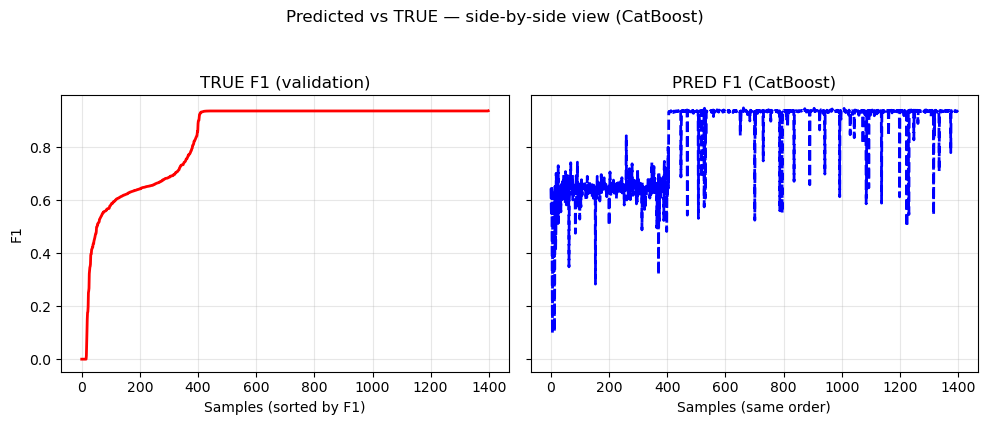

[CatBoost | VAL] RMSE=0.0960 | MAE=0.0366 | R²=0.7012


In [46]:
# Pick best by validation RMSE (from your summary)
best_name = summary.iloc[0]["name"]
best_pred_fn = next(r["predict_fn"] for r in results if r["name"] == best_name)

# Predict on VAL
yhat_val = best_pred_fn(X_va_sur)

# Sort for visual clarity
order = np.argsort(y_va_sur.values)
y_true_sorted = y_va_sur.values[order]
y_pred_sorted = yhat_val[order]

# --- Side-by-side comparison plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# TRUE F1
axes[0].plot(y_true_sorted, "r-", lw=2)
axes[0].set_title("TRUE F1 (validation)")
axes[0].set_xlabel("Samples (sorted by F1)")
axes[0].set_ylabel("F1")
axes[0].grid(alpha=0.3)

# PREDICTED F1
axes[1].plot(y_pred_sorted, "b--", lw=2)
axes[1].set_title(f"PRED F1 ({best_name})")
axes[1].set_xlabel("Samples (same order)")
axes[1].grid(alpha=0.3)

plt.suptitle(f"Predicted vs TRUE — side-by-side view ({best_name})", y=1.05)
plt.tight_layout()
plt.show()

# Validation metrics
rmse_val = float(np.sqrt(mean_squared_error(y_va_sur, yhat_val)))
mae_val  = mean_absolute_error(y_va_sur, yhat_val)
r2_val   = r2_score(y_va_sur, yhat_val)
print(f"[{best_name} | VAL] RMSE={rmse_val:.4f} | MAE={mae_val:.4f} | R²={r2_val:.4f}")


In [47]:
# Build comparison DataFrame
compare_df = pd.DataFrame({
    "f1_true": y_true_sorted,
    "f1_predicted": y_pred_sorted
})

# Compute absolute error
compare_df["abs_error"] = (compare_df["f1_true"] - compare_df["f1_predicted"]).abs()

# Show a representative sample — bottom, middle, top of F1 range
n = len(compare_df)
sample_idx = np.unique(np.clip([0, n//4, n//2, 3*n//4, n-1], 0, n-1))
display(compare_df.iloc[sample_idx].round(4).reset_index(drop=True))

,f1_true,f1_predicted,abs_error
0,0.0000,0.6453,0.6453
1,0.7352,0.6560,0.0792
2,0.9379,0.9425,0.0047
3,0.9379,0.9407,0.0028
4,0.9385,0.9337,0.0048


### Explanations for selected surrogate model


Top-20 CatBoost importances:


,feature,importance
0,user_attrs_resampling_strategy,54.530825
1,params_alpha,9.781452
2,params_gamma,6.418848
3,params_subsample,3.843050
4,params_lambda,2.966319
5,user_attrs_labeled_ratio,2.250841
6,params_selftrain_threshold,1.768785
7,params_max_depth,1.713574
8,user_attrs_feature_fraction,1.662462
9,params_max_delta_step,1.642260


<Figure size 600x600 with 0 Axes>

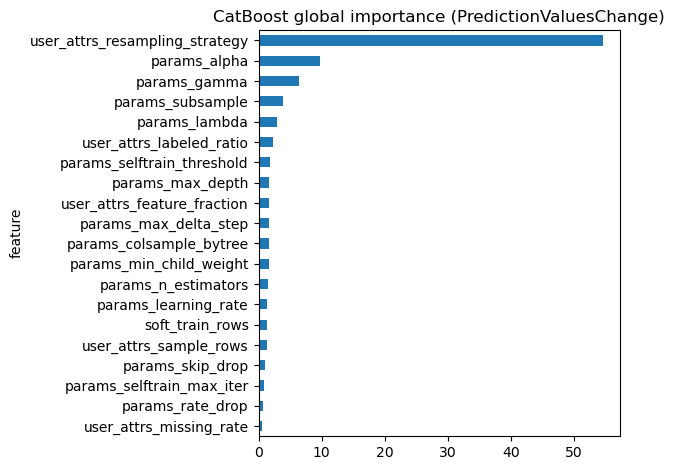

In [15]:
# ---------- CatBoost explanations (fixed: declare cat_features) ----------
# Identify categorical columns and their indices
cat_cols = X_va_sur.select_dtypes(include=["object","category","string"]).columns.tolist()
cat_idx  = [X_va_sur.columns.get_loc(c) for c in cat_cols]

# 1) CatBoost native global importances
pool_va = Pool(
    data=X_va_sur,
    label=y_va_sur,
    feature_names=X_va_sur.columns.tolist(),
    cat_features=cat_idx
)
fi_vals = cb_eval.get_feature_importance(pool_va, type="PredictionValuesChange")
fi_cb = (pd.DataFrame({"feature": X_va_sur.columns, "importance": fi_vals})
         .sort_values("importance", ascending=False)
         .reset_index(drop=True))
print("\nTop-20 CatBoost importances:")
display(fi_cb.head(20))

plt.figure(figsize=(6,6))
fi_cb.head(20).iloc[::-1].plot.barh(x="feature", y="importance", legend=False)
plt.title("CatBoost global importance (PredictionValuesChange)")
plt.tight_layout(); plt.show()


Top-20 Permutation importances (VAL):


,feature,importance_mean,importance_std
0,user_attrs_resampling_strategy,1.270472,0.043396
1,params_alpha,0.122922,0.011181
2,params_gamma,0.021287,0.006961
3,params_subsample,0.019869,0.005821
4,params_lambda,0.018085,0.003034
5,params_max_depth,0.009773,0.002321
6,params_n_estimators,0.008139,0.001559
7,params_max_delta_step,0.007857,0.003081
8,user_attrs_feature_fraction,0.007305,0.001153
9,params_selftrain_threshold,0.005196,0.002083


<Figure size 600x600 with 0 Axes>

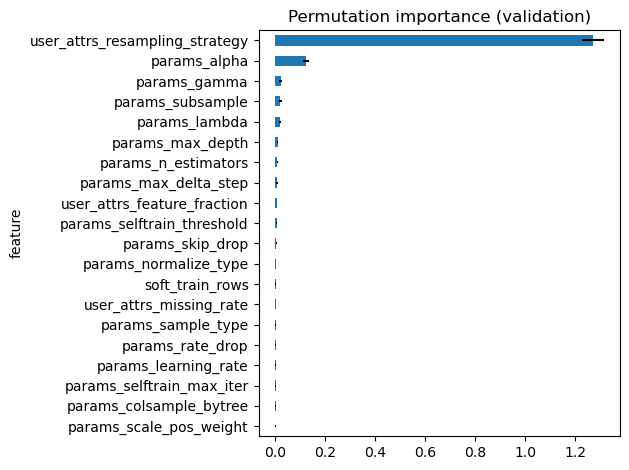

In [16]:
# 2) Permutation importance (validation)
perm = permutation_importance(
    estimator=cb_eval,
    X=X_va_sur, y=y_va_sur,
    n_repeats=10, random_state=0
)
fi_perm = (pd.DataFrame({
    "feature": X_va_sur.columns,
    "importance_mean": perm.importances_mean,
    "importance_std":  perm.importances_std
})
.sort_values("importance_mean", ascending=False)
.reset_index(drop=True))
print("\nTop-20 Permutation importances (VAL):")
display(fi_perm.head(20))

plt.figure(figsize=(6,6))
fi_perm.head(20).iloc[::-1].plot.barh(x="feature", y="importance_mean", xerr="importance_std", legend=False)
plt.title("Permutation importance (validation)")
plt.tight_layout(); plt.show()

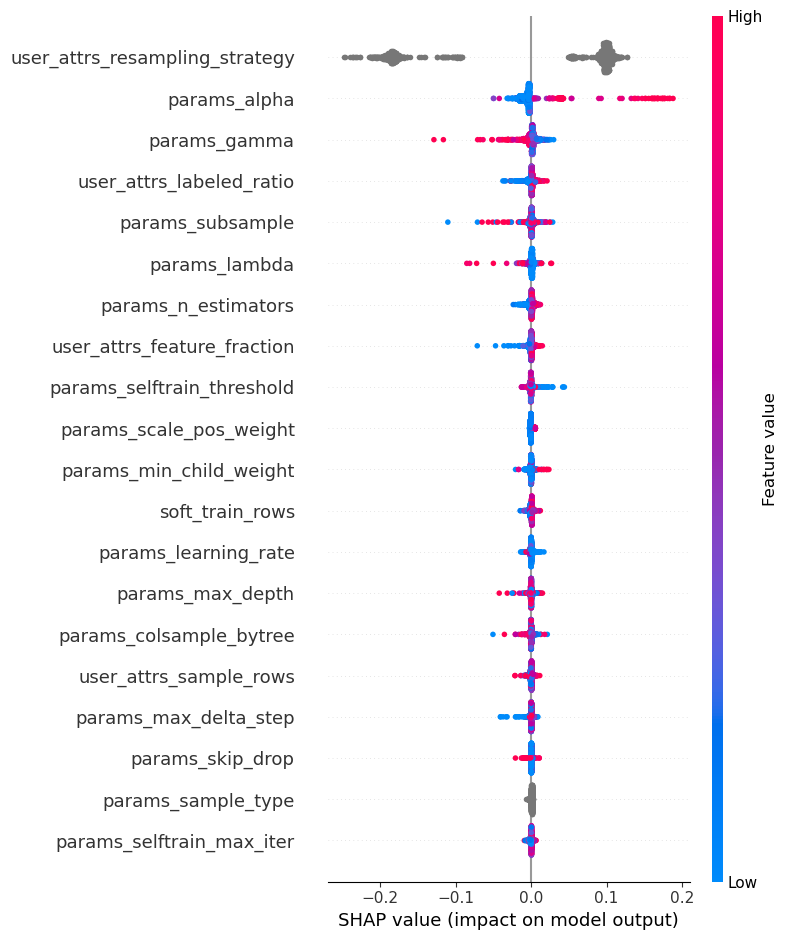

In [17]:
# 3) SHAP values
n_shap = min(2000, len(X_va_sur))
X_shap = X_va_sur.sample(n_shap, random_state=0)
pool_shap = Pool(
    data=X_shap,
    feature_names=X_va_sur.columns.tolist(),
    cat_features=cat_idx
)
explainer = shap.TreeExplainer(cb_eval)
shap_vals = explainer.shap_values(pool_shap)

shap.summary_plot(shap_vals, X_shap, show=True)



Top-20 SHAP |mean impact|:


,feature,mean_abs_shap
0,user_attrs_resampling_strategy,0.125028
1,params_alpha,0.011647
2,params_gamma,0.004729
3,user_attrs_labeled_ratio,0.002625
4,params_subsample,0.002534
5,params_lambda,0.002199
6,params_n_estimators,0.002162
7,user_attrs_feature_fraction,0.001879
8,params_selftrain_threshold,0.001582
9,params_scale_pos_weight,0.001322


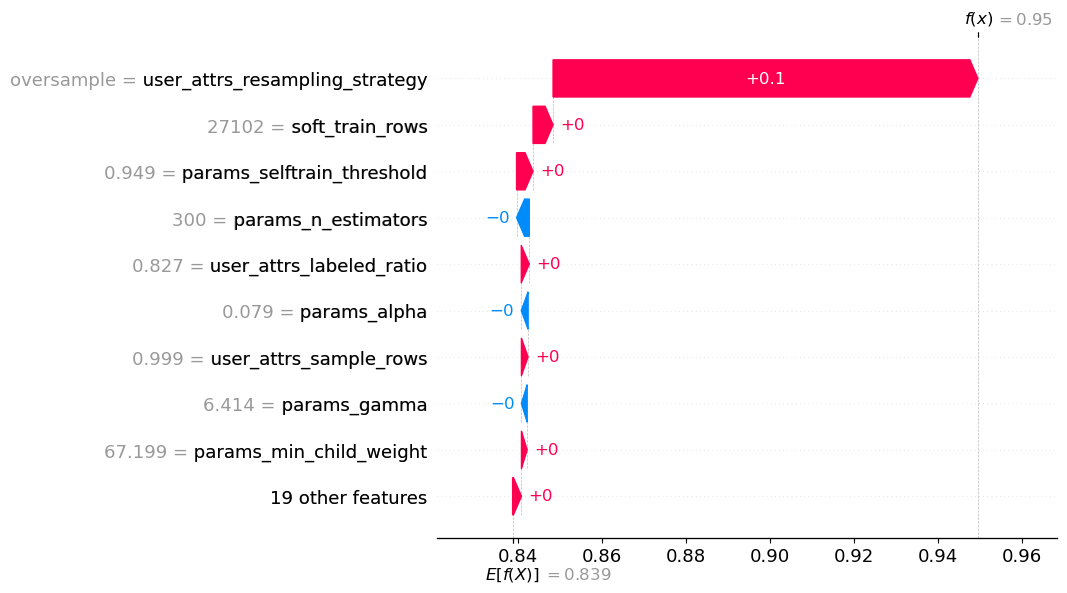

In [18]:
shap_mean = np.abs(shap_vals).mean(axis=0)
fi_shap = (pd.DataFrame({"feature": X_shap.columns, "mean_abs_shap": shap_mean})
           .sort_values("mean_abs_shap", ascending=False)
           .reset_index(drop=True))
print("\nTop-20 SHAP |mean impact|:")
display(fi_shap.head(20))

i_top = int(np.argmax(cb_eval.predict(X_shap)))
shap.plots.waterfall(shap.Explanation(
    values=shap_vals[i_top],
    base_values=explainer.expected_value,
    data=X_shap.iloc[i_top].values,
    feature_names=X_shap.columns.tolist()
))


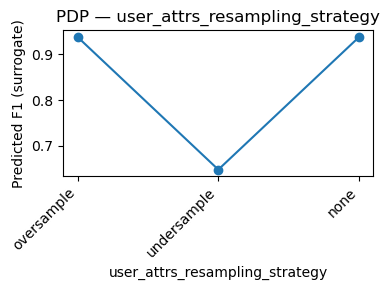

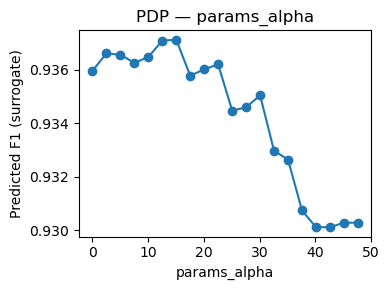

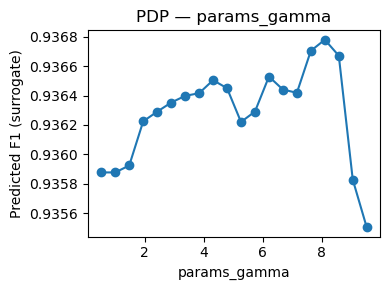

In [19]:
# 4) Simple PDP for top-3 features (by CatBoost importance)
def partial_dependence_1d(model, X_ref, feat, grid=None, n_grid=20, agg=np.median):
    Xb = X_ref.copy()
    x = Xb[feat].to_numpy()
    if grid is None:
        if pd.api.types.is_numeric_dtype(Xb[feat]):
            lo, hi = np.nanpercentile(x, [5, 95]); grid = np.linspace(lo, hi, n_grid)
        else:
            u = pd.Series(x).dropna().unique()
            grid = u if len(u) <= 20 else pd.Series(x).value_counts().head(20).index
    xs, ys = [], []
    for v in grid:
        Xb[feat] = v
        ys.append(cb_eval.predict(Xb).ravel())
        xs.append(v)
    ys = [agg(y) for y in ys]
    return np.array(xs), np.array(ys)

top_k = 3
picked = [f for f in fi_cb["feature"].tolist() if f in X_va_sur.columns][:top_k]

for f in picked:
    gx, gy = partial_dependence_1d(cb_eval, X_va_sur.copy(), f)
    plt.figure(figsize=(4,3))
    if pd.api.types.is_numeric_dtype(X_va_sur[f]):
        plt.plot(gx, gy, marker="o")
        plt.xlabel(f)
    else:
        xs = np.arange(len(gx))
        plt.plot(xs, gy, marker="o")
        plt.xticks(xs, [str(t) for t in gx], rotation=45, ha="right")
        plt.xlabel(f)
    plt.ylabel("Predicted F1 (surrogate)")
    plt.title(f"PDP — {f}")
    plt.tight_layout(); plt.show()


In [20]:
# 5) Unified table
report = (fi_cb[["feature","importance"]]
          .merge(fi_perm[["feature","importance_mean"]], on="feature", how="outer")
          .merge(fi_shap[["feature","mean_abs_shap"]], on="feature", how="outer")
          .fillna(0.0)
          .sort_values(["importance","importance_mean","mean_abs_shap"], ascending=False))
print("\nUnified importance table:")
display(report.head(30))


Unified importance table:


,feature,importance,importance_mean,mean_abs_shap
26,user_attrs_resampling_strategy,54.530825,1.270472,0.125028
0,params_alpha,9.781452,0.122922,0.011647
3,params_gamma,6.418848,0.021287,0.004729
18,params_subsample,3.843050,0.019869,0.002534
5,params_lambda,2.966319,0.018085,0.002199
24,user_attrs_labeled_ratio,2.250841,-0.003435,0.002625
16,params_selftrain_threshold,1.768785,0.005196,0.001582
8,params_max_depth,1.713574,0.009773,0.001149
23,user_attrs_feature_fraction,1.662462,0.007305,0.001879
7,params_max_delta_step,1.642260,0.007857,0.001112


## Generating counterfactuals

### Configs and seed selection

In [48]:
# ============================== CONFIG ==============================
low, high = 0.6, 0.80      # desired F1 range (surrogate-based)
TOTAL_CFS = 20              # number of CFs from DiCE
K = 5                       # robustness repeats
AGG = "median"              # "mean" or "median"
BASE_SEED = 12345           # base RNG seed

In [49]:
# ---------- Pick a seed INSIDE the desired range (by surrogate) ----------
f1_hat_all = cb_eval.predict(X_sur).astype(float)
mask_in = (f1_hat_all >= low) & (f1_hat_all <= high)
if not mask_in.any():
    raise RuntimeError(f"No seed found with surrogate F1 in [{low}, {high}]. Widen the range.")
np.random.seed(0)
seed_idx = int(np.random.choice(np.where(mask_in)[0], 1))
seed = X_sur.iloc[[seed_idx]]
print("Picked seed index:", seed_idx, "| surrogate F1:", float(f1_hat_all[seed_idx]))
display(seed.T)


Picked seed index: 2596 | surrogate F1: 0.6888937822606614


/tmp/ipykernel_2021257/1245142222.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  seed_idx = int(np.random.choice(np.where(mask_in)[0], 1))


,2596
params_alpha,0.002987
params_booster,dart
params_colsample_bytree,0.200689
params_gamma,2.085579
params_grow_policy,lossguide
params_lambda,0.003454
params_learning_rate,0.149145
params_max_delta_step,4
params_max_depth,4
params_min_child_weight,33.281627


## CF genegration with DiCE

In [50]:
# Data + Model
data_dice  = dice_ml.Data(
    dataframe=pd.concat([X_sur, y_sur], axis=1),
    continuous_features=num_cols,
    categorical_features=cat_cols,
    outcome_name="f1",
)
model_dice = dice_ml.Model(model=cb_eval, backend="sklearn", model_type="regressor")
exp        = Dice(data_dice, model_dice, method="genetic")

In [51]:
# ---------- Build permitted_range: vary only hard knobs; freeze soft to seed ----------
permitted_range = {
    "params_learning_rate": [1e-4, 0.5],
    "params_max_depth":     [3, 12],
    "params_n_estimators":  [200, 1000],
    "params_booster":       ["gbtree", "dart"],
}

soft_cols = [
    "user_attrs_decision_threshold",
    "user_attrs_feature_fraction",
    "user_attrs_resampling_strategy",
    "user_attrs_sample_rows",
    "user_attrs_labeled_ratio",
    "user_attrs_missing_rate",
    "params_selftrain_max_iter",
    "params_selftrain_threshold",
    "soft_risk_preference",
    "soft_decision_speed",
    "soft_train_rows",
]

for c in soft_cols:
    if c in X_sur.columns:
        v = seed.iloc[0][c]
        if pd.api.types.is_numeric_dtype(X_sur[c]):
            permitted_range[c] = [float(v), float(v)]
        else:
            permitted_range[c] = [str(v)]

In [53]:
# ---------- Generate CFs with DiCE ----------
cf = exp.generate_counterfactuals(
    query_instances=seed,
    total_CFs=TOTAL_CFS,
    desired_range=[low, high],
    #features_to_vary=list(permitted_range.keys()),
    features_to_vary="all",
    permitted_range=permitted_range,
)
cf_df = cf.cf_examples_list[0].final_cfs_df.copy()
print(f"Counterfactuals found: {len(cf_df)}")
display(cf_df.head(10))


  0%|          | 0/1 [00:00<?, ?it/s]/home/jovyan/.conda/envs/env_hpo_xai/lib/python3.11/site-packages/dice_ml/explainer_interfaces/dice_genetic.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  feature_weights_list.append(round(1 / self.feature_range[feature].max(), 2))
100%|██████████| 1/1 [00:01<00:00,  1.77s/it]

Counterfactuals found: 20


,params_alpha,params_booster,params_colsample_bytree,params_gamma,params_grow_policy,params_lambda,params_learning_rate,params_max_delta_step,params_max_depth,params_min_child_weight,params_n_estimators,params_normalize_type,params_scale_pos_weight,params_rate_drop,params_sample_type,params_skip_drop,params_subsample,user_attrs_decision_threshold,user_attrs_feature_fraction,user_attrs_resampling_strategy,user_attrs_sample_rows,user_attrs_labeled_ratio,user_attrs_missing_rate,params_selftrain_max_iter,params_selftrain_threshold,soft_risk_preference,soft_decision_speed,soft_train_rows,f1
0,0.002987,dart,0.200689,2.085579,lossguide,0.003454,0.149145,4,4,33.281628,900,forest,1.0,0.4,weighted,0.3,0.394468,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451,0.688894
0,0.000100,dart,0.492662,2.085579,depthwise,36.408127,0.149145,4,4,33.281628,900,forest,1.0,0.4,weighted,0.3,0.394468,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451,0.617115
0,0.000100,dart,0.492662,0.002001,lossguide,0.000100,0.149145,4,3,33.281628,900,forest,1.0,0.4,weighted,0.0,0.200223,0.5,0.586978,undersample,0.643338,1.000000,0.02,6.0,0.733854,recall_pref,balanced,17451,0.678456
0,0.000100,dart,0.492662,2.085579,depthwise,0.000100,0.149145,1,4,33.281628,900,forest,0.5,0.0,weighted,0.0,0.394468,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451,0.654979
0,0.000100,dart,0.200393,0.002001,lossguide,0.003454,0.149145,8,10,0.201332,200,NA,1.0,0.4,weighted,0.3,0.609403,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451,0.610409
0,0.000100,dart,0.492662,0.002001,lossguide,0.000100,0.149145,4,7,0.100236,200,forest,1.0,0.4,weighted,0.0,0.835147,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451,0.643097
0,0.002227,gbtree,0.200689,0.002001,lossguide,0.003454,0.098381,7,4,0.147510,900,NA,1.0,0.4,NA,0.3,0.394468,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451,0.658959
0,0.000100,dart,0.492662,0.370136,depthwise,0.000100,0.105586,0,4,33.281628,900,forest,1.0,0.4,weighted,0.3,0.200223,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451,0.652634
0,0.000100,dart,0.200393,0.002001,lossguide,0.000100,0.149145,1,3,0.100236,200,NA,1.0,0.4,weighted,0.3,0.200223,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451,0.618448
0,0.000100,dart,0.200393,0.002001,lossguide,0.000100,0.149145,1,9,0.100236,900,NA,1.0,0.0,weighted,0.3,0.200223,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451,0.660014


### Evaluating counterfactuals

#### Passing dice params to surrogate model and comparing surrogate f1 with dice f1

In [54]:
# ---------- Score CFs with surrogate (fast) ----------
cf_sur = cf_df.copy()
extra_cols = [c for c in cf_sur.columns if c not in X_sur.columns]
if extra_cols:
    cf_sur = cf_sur.drop(columns=extra_cols, errors="ignore")
cf_sur = cf_sur.reindex(columns=X_sur.columns)
if "params_booster" in cf_sur.columns:
    nd = cf_sur["params_booster"].astype(str) != "dart"
    for c in ("params_rate_drop","params_skip_drop"):
        if c in cf_sur.columns: cf_sur.loc[nd, c] = 0.0
    for c in ("params_sample_type","params_normalize_type"):
        if c in cf_sur.columns: cf_sur.loc[nd, c] = "NA"

f1_sur_cf = cb_eval.predict(cf_sur).astype(float)

out = cf_df.rename(columns={"f1": "f1_dice"}).copy()
out["f1_surrogate"] = f1_sur_cf
out["delta_surrogate_minus_dice"] = out["f1_surrogate"] - pd.to_numeric(out["f1_dice"], errors="coerce")

# (Optional) show the score columns first
cols_first = ["f1_dice", "f1_surrogate", "delta_surrogate_minus_dice"]
cols_order = [c for c in cols_first if c in out.columns] + [c for c in out.columns if c not in cols_first]
display(out[cols_order].head(20))


,f1_dice,f1_surrogate,delta_surrogate_minus_dice,params_alpha,params_booster,params_colsample_bytree,params_gamma,params_grow_policy,params_lambda,params_learning_rate,params_max_delta_step,params_max_depth,params_min_child_weight,params_n_estimators,params_normalize_type,params_scale_pos_weight,params_rate_drop,params_sample_type,params_skip_drop,params_subsample,user_attrs_decision_threshold,user_attrs_feature_fraction,user_attrs_resampling_strategy,user_attrs_sample_rows,user_attrs_labeled_ratio,user_attrs_missing_rate,params_selftrain_max_iter,params_selftrain_threshold,soft_risk_preference,soft_decision_speed,soft_train_rows
0,0.688894,0.688894,0.000000,0.002987,dart,0.200689,2.085579,lossguide,0.003454,0.149145,4,4,33.281628,900,forest,1.0,0.4,weighted,0.3,0.394468,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451
0,0.617115,0.617115,0.000000,0.000100,dart,0.492662,2.085579,depthwise,36.408127,0.149145,4,4,33.281628,900,forest,1.0,0.4,weighted,0.3,0.394468,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451
0,0.678456,0.678456,0.000000,0.000100,dart,0.492662,0.002001,lossguide,0.000100,0.149145,4,3,33.281628,900,forest,1.0,0.4,weighted,0.0,0.200223,0.5,0.586978,undersample,0.643338,1.000000,0.02,6.0,0.733854,recall_pref,balanced,17451
0,0.654979,0.654979,0.000000,0.000100,dart,0.492662,2.085579,depthwise,0.000100,0.149145,1,4,33.281628,900,forest,0.5,0.0,weighted,0.0,0.394468,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451
0,0.610409,0.610409,0.000000,0.000100,dart,0.200393,0.002001,lossguide,0.003454,0.149145,8,10,0.201332,200,NA,1.0,0.4,weighted,0.3,0.609403,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451
0,0.643097,0.643097,0.000000,0.000100,dart,0.492662,0.002001,lossguide,0.000100,0.149145,4,7,0.100236,200,forest,1.0,0.4,weighted,0.0,0.835147,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451
0,0.658959,0.661026,0.002067,0.002227,gbtree,0.200689,0.002001,lossguide,0.003454,0.098381,7,4,0.147510,900,NA,1.0,0.4,NA,0.3,0.394468,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451
0,0.652634,0.652634,0.000000,0.000100,dart,0.492662,0.370136,depthwise,0.000100,0.105586,0,4,33.281628,900,forest,1.0,0.4,weighted,0.3,0.200223,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451
0,0.618448,0.618448,0.000000,0.000100,dart,0.200393,0.002001,lossguide,0.000100,0.149145,1,3,0.100236,200,NA,1.0,0.4,weighted,0.3,0.200223,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451
0,0.660014,0.660014,0.000000,0.000100,dart,0.200393,0.002001,lossguide,0.000100,0.149145,1,9,0.100236,900,NA,1.0,0.0,weighted,0.3,0.200223,0.5,0.586978,undersample,0.643338,0.697464,0.02,6.0,0.733854,recall_pref,balanced,17451


#### Evaluating by refitting xgboost and observing cfs f1 and real f1 gaps

In [55]:
# ---------- Robust XGBoost eval with K different random applications of soft knobs ----------
def _inject_missing(X_df, num_cols, cat_cols, rate, rng):
    if rate <= 0: return X_df.copy()
    Xm = X_df.copy(); n = len(Xm)
    for c in num_cols:
        m = rng.random(n) < rate
        if m.all(): m[rng.integers(0, n)] = False
        Xm.loc[m, c] = np.nan
    for c in cat_cols:
        m = rng.random(n) < rate
        if m.all(): m[rng.integers(0, n)] = False
        Xm.loc[m, c] = np.nan
    return Xm

def _stack_rows(A, B):
    import scipy.sparse as sp
    if sp.issparse(A) or sp.issparse(B):
        A = A.tocsr() if sp.issparse(A) else sp.csr_matrix(A)
        B = B.tocsr() if sp.issparse(B) else sp.csr_matrix(B)
        return sp.vstack([A, B], format="csr")
    return np.vstack([A, B])

preproc = ColumnTransformer([
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore"))]), cat),
    ("num", "passthrough", num),
])

def eval_once(row, seed_int):
    rng_rows = np.random.default_rng(seed_int)

    y_tr_np = np.asarray(y_tr, dtype=int)
    pos = np.where(y_tr_np == 1)[0]; neg = np.where(y_tr_np == 0)[0]
    sample_rows = float(row.get("user_attrs_sample_rows", row.get("params_sample_rows", 1.0)))
    sample_rows = float(np.clip(sample_rows, 0.5, 1.0))
    n_pos = max(1, int(len(pos) * sample_rows)); n_neg = max(1, int(len(neg) * sample_rows))
    keep = np.concatenate([rng_rows.choice(pos, n_pos, replace=False),
                           rng_rows.choice(neg, n_neg, replace=False)])
    rng_rows.shuffle(keep)

    u = float(row.get("params_missing_rate", 0.0))
    grid = np.array([0.00, 0.02, 0.05, 0.08, 0.10])
    missing_rate = float(grid[np.argmin(np.abs(grid - u))])
    rng_mask = np.random.default_rng((seed_int, int(round(missing_rate * 100))))
    X_tr_masked = _inject_missing(X_tr.iloc[keep], num, cat, missing_rate, rng_mask)

    Xtr_enc = preproc.fit_transform(X_tr_masked)
    Xva_enc = preproc.transform(X_va)
    Xte_enc = preproc.transform(X_te)

    params = dict(
        booster=str(row.get("params_booster","gbtree")),
        n_estimators=int(row.get("params_n_estimators", 400)),
        max_depth=int(row.get("params_max_depth", 6)),
        learning_rate=float(row.get("params_learning_rate", 0.1)),
        min_child_weight=float(row.get("params_min_child_weight", 1.0)),
        gamma=float(row.get("params_gamma", 0.0)),
        reg_lambda=float(row.get("params_lambda", 1.0)),
        reg_alpha=float(row.get("params_alpha", 0.0)),
        subsample=float(row.get("params_subsample", 0.8)),
        colsample_bytree=float(row.get("params_colsample_bytree", 0.8)),
        grow_policy=str(row.get("params_grow_policy","depthwise")),
        max_delta_step=int(row.get("params_max_delta_step", 0)),
        objective="binary:logistic",
        eval_metric="error",
        tree_method="hist",
        device="cuda",
        missing=np.nan,
        random_state=0,
        verbosity=0,
    )
    if params["booster"] == "dart":
        st = str(row.get("params_sample_type","uniform"))
        nt = str(row.get("params_normalize_type","tree"))
        params.update(
            rate_drop=float(row.get("params_rate_drop", 0.0)),
            skip_drop=float(row.get("params_skip_drop", 0.0)),
            sample_type=st if st in {"uniform","weighted"} else "uniform",
            normalize_type=nt if nt in {"tree","forest"} else "tree",
        )

    ytr_sub = y_tr_np[keep].astype(int)
    resampling = str(row.get("user_attrs_resampling_strategy",
                             row.get("params_resampling","none"))).strip().lower()
    if resampling not in {"none","undersample","oversample"}:
        resampling = "none"
    if resampling != "none":
        params["scale_pos_weight"] = 1.0
        posk, negk = np.where(ytr_sub == 1)[0], np.where(ytr_sub == 0)[0]
        if len(posk) and len(negk):
            if resampling == "undersample":
                n = min(len(posk), len(negk))
                idx = np.concatenate([rng_rows.choice(posk, n, replace=False),
                                      rng_rows.choice(negk, n, replace=False)])
                Xtr_enc, ytr_sub = Xtr_enc[idx], ytr_sub[idx]
            elif resampling == "oversample":
                n = max(len(posk), len(negk))
                addp = rng_rows.choice(posk, n - len(posk), replace=True) if len(posk) < n else np.array([], int)
                addn = rng_rows.choice(negk, n - len(negk), replace=True) if len(negk) < n else np.array([], int)
                add = np.concatenate([addp, addn])
                if add.size:
                    Xtr_enc = _stack_rows(Xtr_enc, Xtr_enc[add])
                    ytr_sub = np.concatenate([ytr_sub, ytr_sub[add]]).astype(int)
    else:
        params["scale_pos_weight"] = float(row.get("params_scale_pos_weight", 1.0))

    ff = float(row.get("user_attrs_feature_fraction", row.get("params_feature_fraction", 1.0)))
    ff = float(np.clip(ff, 0.5, 1.0))
    nF = Xtr_enc.shape[1]; kF = max(1, int(nF * ff))
    feat_idx = np.sort(np.random.default_rng(seed_int+999).choice(np.arange(nF), size=kF, replace=False))
    Xtr_sub, Xva_sub, Xte_sub = Xtr_enc[:, feat_idx], Xva_enc[:, feat_idx], Xte_enc[:, feat_idx]

    labeled_ratio = float(row.get("params_labeled_ratio", row.get("user_attrs_labeled_ratio", 1.0)))
    if labeled_ratio < 1.0 and len(np.unique(ytr_sub)) == 2:
        from sklearn.semi_supervised import SelfTrainingClassifier
        pidx, nidx = np.where(ytr_sub == 1)[0], np.where(ytr_sub == 0)[0]
        kp = max(1, int(round(len(pidx)*labeled_ratio))); kp = min(kp, len(pidx))
        kn = max(1, int(round(len(nidx)*labeled_ratio))); kn = min(kn, len(nidx))
        rngP, rngN = np.random.default_rng(seed_int+123), np.random.default_rng(seed_int+456)
        keep_lab = np.concatenate([
            rngP.choice(pidx, kp, replace=False),
            rngN.choice(nidx, kn, replace=False)
        ])
        ysemi = np.full_like(ytr_sub, -1)
        ysemi[keep_lab] = ytr_sub[keep_lab]

        # ---- clamp self-training threshold to [0, 1) ----
        thr_semi = float(row.get("params_selftrain_threshold", 0.7))
        thr_semi = float(np.clip(thr_semi, 0.0, np.nextafter(1.0, 0.0)))
        # -----------------------------------------------

        clf = SelfTrainingClassifier(
            estimator=xgb.XGBClassifier(**params),
            threshold=thr_semi,
            max_iter=int(row.get("params_selftrain_max_iter", 8)),
            verbose=False
        ).fit(Xtr_sub, ysemi)
    else:
        clf = xgb.XGBClassifier(**params).fit(Xtr_sub, ytr_sub)

    thr = float(row.get("user_attrs_decision_threshold", 0.5))

    y_va_int = np.asarray(y_va, int); y_te_int = np.asarray(y_te, int)
    proba_va = clf.predict_proba(Xva_sub)[:, 1]
    proba_te = clf.predict_proba(Xte_sub)[:, 1]
    yhat_va = (proba_va >= thr).astype(int)
    yhat_te = (proba_te >= thr).astype(int)

    return dict(
        f1_val=float(f1_score(y_va_int, yhat_va, zero_division=0)),
        f1_test=float(f1_score(y_te_int, yhat_te, zero_division=0)),
    )

def eval_k(row_dict, K=5, base_seed=12345, agg="median"):
    seeds = [base_seed + i for i in range(K)]
    outs = [eval_once(row_dict, s) for s in seeds]
    aggfun = np.median if agg == "median" else np.mean
    return {
        "f1_val": float(aggfun([o["f1_val"] for o in outs])),
        "f1_test": float(aggfun([o["f1_test"] for o in outs])),
        "f1_val_std": float(np.std([o["f1_val"] for o in outs])),
        "f1_test_std": float(np.std([o["f1_test"] for o in outs])),
        "n_runs": K,
        "seed0": seeds[0],
        "seed_last": seeds[-1],
    }

rows = []
for i in range(len(cf_df)):
    r = cf_df.iloc[i].to_dict()
    m = eval_k(r, K=K, base_seed=BASE_SEED + i*1000, agg=AGG)
    m["cf_index"] = i
    m["f1_surrogate"] = float(f1_sur_cf[i])
    if "f1" in cf_df.columns:
        m["f1_dice"] = float(cf_df.iloc[i]["f1"])
        m["delta_surrogate_minus_dice"] = m["f1_surrogate"] - m["f1_dice"]
    rows.append(m)

results_k = pd.DataFrame(rows).sort_values("f1_test", ascending=False)
display(results_k.head(10))


,f1_val,f1_test,f1_val_std,f1_test_std,n_runs,seed0,seed_last,cf_index,f1_surrogate,f1_dice,delta_surrogate_minus_dice
15,0.893424,0.891844,0.034347,0.038008,5,27345,27349,15,0.625181,0.625181,0.000000
14,0.893677,0.889418,0.045509,0.043541,5,26345,26349,14,0.654657,0.654657,0.000000
5,0.890321,0.887802,0.007480,0.008302,5,17345,17349,5,0.643097,0.643097,0.000000
6,0.887253,0.883438,0.031832,0.031810,5,18345,18349,6,0.661026,0.658959,0.002067
11,0.872459,0.872042,0.027786,0.029497,5,23345,23349,11,0.647882,0.647788,0.000094
4,0.871997,0.871993,0.015736,0.015325,5,16345,16349,4,0.610409,0.610409,0.000000
18,0.873381,0.871194,0.055023,0.055307,5,30345,30349,18,0.613823,0.622768,-0.008944
13,0.875052,0.870236,0.003801,0.003734,5,25345,25349,13,0.603377,0.603377,0.000000
19,0.869884,0.867450,0.036952,0.037238,5,31345,31349,19,0.633082,0.633082,0.000000
2,0.855670,0.853153,0.052701,0.054853,5,14345,14349,2,0.678456,0.678456,0.000000


## CF generation with CFNOW

In [284]:
# ---------------- CFNOW CONFIG ----------------
CFNOW_MAX_CFS = TOTAL_CFS
CFNOW_TIME_LIMIT = 30  # seconds

# Numeric features CFNOW is allowed to change
num_cf_features = [
    "params_alpha",
    "params_colsample_bytree",
    "params_gamma",
    "params_lambda",
    "params_learning_rate",
    "params_max_delta_step",
    "params_max_depth",
    "params_min_child_weight",
    "params_n_estimators",
    "params_scale_pos_weight",
    "params_rate_drop",
    "params_skip_drop",
    "params_subsample",
    "user_attrs_decision_threshold",
    "user_attrs_feature_fraction",
    "user_attrs_sample_rows",
    "params_labeled_ratio",
    "params_missing_rate",
    "params_selftrain_max_iter",
    "params_selftrain_threshold",
    "user_attrs_labeled_ratio",
    "user_attrs_missing_rate",
    "soft_train_rows",
]

# keep only those present
num_cf_features = [c for c in num_cf_features if c in X_sur.columns]

print("[CFNOW] numeric features used for search:", len(num_cf_features))
print(num_cf_features)

# factual = seed row restricted to numeric CF features
x_factual = seed[num_cf_features].iloc[0].astype(float)

# ---------------- link CFNOW -> CatBoost surrogate ----------------
def model_predict_proba_cfnow(X_num):
    X_num = np.asarray(X_num)
    if X_num.ndim == 1:
        X_num = X_num.reshape(1, -1)

    # Build full config: start from seed, overwrite numeric features with X_num
    X_df = pd.DataFrame(X_num, columns=num_cf_features)
    base = pd.concat([seed] * len(X_df), ignore_index=True)
    for c in num_cf_features:
        base[c] = X_df[c].astype(float)

    f1_pred = cb_eval.predict(base).astype(float)

    thr = float(seed["user_attrs_decision_threshold"].iloc[0]) if "user_attrs_decision_threshold" in seed.columns else 0.5
    scale = 15.0
    p1 = 1.0 / (1.0 + np.exp(-scale * (f1_pred - thr)))
    p0 = 1.0 - p1
    return np.column_stack([p0, p1])

# ---------------- run CFNOW search ----------------
cf_obj = find_tabular(
    factual=x_factual,
    model_predict_proba=model_predict_proba_cfnow,
    count_cf=CFNOW_MAX_CFS,
    limit_seconds=CFNOW_TIME_LIMIT,
    verbose=True,
)

# cfs → numpy
cfnow_arr = np.array(cf_obj.cfs)

# 1) deduplicate
cfnow_arr_unique = np.unique(cfnow_arr, axis=0)
cfnow_num_df = pd.DataFrame(cfnow_arr_unique, columns=num_cf_features)

# 2) rebuild full configs from seed
cf_full = pd.concat([seed] * len(cfnow_num_df), ignore_index=True)
for c in num_cf_features:
    cf_full[c] = cfnow_num_df[c].astype(float)

# 3) clip obvious bounded knobs
for col in ["params_missing_rate", "user_attrs_missing_rate",
            "params_labeled_ratio", "user_attrs_labeled_ratio"]:
    if col in cf_full.columns:
        cf_full[col] = cf_full[col].clip(0.0, 1.0)

if "user_attrs_decision_threshold" in cf_full.columns:
    cf_full["user_attrs_decision_threshold"] = cf_full["user_attrs_decision_threshold"].clip(0.0, 1.0)

# 4) score with surrogate using the same target name as DiCE
cf_full["f1"] = cb_eval.predict(cf_full).astype(float)

# final CF dataframe (same name / schema convention as DiCE)
cf_df = cf_full.copy()

print(f"[CFNOW] Counterfactuals found: {len(cf_df)}")
display(cf_df.head(20))


[CFNOW] numeric features used for search: 22
['params_alpha', 'params_colsample_bytree', 'params_gamma', 'params_lambda', 'params_learning_rate', 'params_max_delta_step', 'params_max_depth', 'params_min_child_weight', 'params_n_estimators', 'params_scale_pos_weight', 'params_rate_drop', 'params_skip_drop', 'params_subsample', 'user_attrs_feature_fraction', 'user_attrs_sample_rows', 'params_labeled_ratio', 'params_missing_rate', 'params_selftrain_max_iter', 'params_selftrain_threshold', 'user_attrs_labeled_ratio', 'user_attrs_missing_rate', 'soft_train_rows']
[CFNOW] Counterfactuals found: 4476


,params_alpha,params_booster,params_colsample_bytree,params_gamma,params_grow_policy,params_lambda,params_learning_rate,params_max_delta_step,params_max_depth,params_min_child_weight,params_n_estimators,params_normalize_type,params_scale_pos_weight,params_rate_drop,params_sample_type,params_skip_drop,params_subsample,user_attrs_feature_fraction,user_attrs_resampling_strategy,user_attrs_sample_rows,params_labeled_ratio,params_missing_rate,params_selftrain_max_iter,params_selftrain_threshold,user_attrs_labeled_ratio,user_attrs_missing_rate,soft_risk_preference,soft_decision_speed,soft_train_rows,f1
0,2.475589,dart,0.743355,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.691069,0.531357,0.835155,oversample,0.980397,0.828592,0.046881,10.0,0.736567,0.911451,0.03727,recall_pref,balanced,6503.0,0.494470
1,2.475589,dart,0.743355,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.697409,0.531357,0.835155,oversample,0.980397,0.828592,0.046881,10.0,0.729871,0.911451,0.03727,recall_pref,balanced,6503.0,0.494470
2,2.475589,dart,0.743355,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.697409,0.531357,0.835155,oversample,0.980397,0.828592,0.046881,10.0,0.736567,0.903165,0.03727,recall_pref,balanced,6503.0,0.494470
3,2.475589,dart,0.743355,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.697409,0.531357,0.835155,oversample,0.980397,0.828592,0.046881,10.0,0.736567,0.911451,0.03727,recall_pref,balanced,6503.0,0.494470
4,2.475589,dart,0.743355,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.697409,0.531357,0.835155,oversample,0.980397,0.828592,0.047402,10.0,0.736567,0.911451,0.03727,recall_pref,balanced,6503.0,0.494470
5,2.475589,dart,0.743355,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.697409,0.537261,0.835155,oversample,0.980397,0.828592,0.046881,10.0,0.736567,0.911451,0.03727,recall_pref,balanced,6503.0,0.493748
6,2.475589,dart,0.743355,8.921018,lossguide,0.001657,0.000744,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.697409,0.531357,0.835155,oversample,0.980397,0.828592,0.046881,10.0,0.736567,0.911451,0.03727,recall_pref,balanced,6503.0,0.494470
7,2.475589,dart,0.751614,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.697409,0.531357,0.835155,oversample,0.980397,0.828592,0.046881,10.0,0.736567,0.911451,0.03727,recall_pref,balanced,6503.0,0.493157
8,2.644770,dart,0.743355,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.653904,0.531357,0.835155,oversample,0.980397,0.828592,0.046881,10.0,0.736567,0.911451,0.03727,recall_pref,balanced,6503.0,0.494368
9,2.644770,dart,0.743355,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.653904,0.531357,0.835155,oversample,0.980397,0.828592,0.047402,10.0,0.736567,0.911451,0.03727,recall_pref,balanced,6503.0,0.494368


#### same evaluation for cfnow

In [285]:
# ---------- Score CFNOW CFs with surrogate (fast) ----------
cf_sur = cf_df.copy()
extra_cols = [c for c in cf_sur.columns if c not in X_sur.columns]
if extra_cols:
    cf_sur = cf_sur.drop(columns=extra_cols, errors="ignore")
cf_sur = cf_sur.reindex(columns=X_sur.columns)

if "params_booster" in cf_sur.columns:
    nd = cf_sur["params_booster"].astype(str) != "dart"
    for c in ("params_rate_drop","params_skip_drop"):
        if c in cf_sur.columns:
            cf_sur.loc[nd, c] = 0.0
    for c in ("params_sample_type","params_normalize_type"):
        if c in cf_sur.columns:
            cf_sur.loc[nd, c] = "NA"

# surrogate prediction on cleaned CFNOW configs
f1_sur_cfnow = cb_eval.predict(cf_sur).astype(float)

# same pattern as DiCE: rename original f1 and compare to surrogate
out_cfnow = cf_df.rename(columns={"f1": "f1_cfnow"}).copy()
out_cfnow["f1_surrogate"] = f1_sur_cfnow
out_cfnow["delta_surrogate_minus_cfnow"] = (
    out_cfnow["f1_surrogate"] - pd.to_numeric(out_cfnow["f1_cfnow"], errors="coerce")
)

# show score columns first
cols_first = ["f1_cfnow", "f1_surrogate", "delta_surrogate_minus_cfnow"]
cols_order = [c for c in cols_first if c in out_cfnow.columns] + \
             [c for c in out_cfnow.columns if c not in cols_first]

display(out_cfnow[cols_order].head(20))


,f1_cfnow,f1_surrogate,delta_surrogate_minus_cfnow,params_alpha,params_booster,params_colsample_bytree,params_gamma,params_grow_policy,params_lambda,params_learning_rate,params_max_delta_step,params_max_depth,params_min_child_weight,params_n_estimators,params_normalize_type,params_scale_pos_weight,params_rate_drop,params_sample_type,params_skip_drop,params_subsample,user_attrs_feature_fraction,user_attrs_resampling_strategy,user_attrs_sample_rows,params_labeled_ratio,params_missing_rate,params_selftrain_max_iter,params_selftrain_threshold,user_attrs_labeled_ratio,user_attrs_missing_rate,soft_risk_preference,soft_decision_speed,soft_train_rows
0,0.494470,0.494470,0.0,2.475589,dart,0.743355,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.691069,0.531357,0.835155,oversample,0.980397,0.828592,0.046881,10.0,0.736567,0.911451,0.03727,recall_pref,balanced,6503.0
1,0.494470,0.494470,0.0,2.475589,dart,0.743355,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.697409,0.531357,0.835155,oversample,0.980397,0.828592,0.046881,10.0,0.729871,0.911451,0.03727,recall_pref,balanced,6503.0
2,0.494470,0.494470,0.0,2.475589,dart,0.743355,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.697409,0.531357,0.835155,oversample,0.980397,0.828592,0.046881,10.0,0.736567,0.903165,0.03727,recall_pref,balanced,6503.0
3,0.494470,0.494470,0.0,2.475589,dart,0.743355,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.697409,0.531357,0.835155,oversample,0.980397,0.828592,0.046881,10.0,0.736567,0.911451,0.03727,recall_pref,balanced,6503.0
4,0.494470,0.494470,0.0,2.475589,dart,0.743355,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.697409,0.531357,0.835155,oversample,0.980397,0.828592,0.047402,10.0,0.736567,0.911451,0.03727,recall_pref,balanced,6503.0
5,0.493748,0.493748,0.0,2.475589,dart,0.743355,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.697409,0.537261,0.835155,oversample,0.980397,0.828592,0.046881,10.0,0.736567,0.911451,0.03727,recall_pref,balanced,6503.0
6,0.494470,0.494470,0.0,2.475589,dart,0.743355,8.921018,lossguide,0.001657,0.000744,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.697409,0.531357,0.835155,oversample,0.980397,0.828592,0.046881,10.0,0.736567,0.911451,0.03727,recall_pref,balanced,6503.0
7,0.493157,0.493157,0.0,2.475589,dart,0.751614,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.697409,0.531357,0.835155,oversample,0.980397,0.828592,0.046881,10.0,0.736567,0.911451,0.03727,recall_pref,balanced,6503.0
8,0.494368,0.494368,0.0,2.644770,dart,0.743355,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.653904,0.531357,0.835155,oversample,0.980397,0.828592,0.046881,10.0,0.736567,0.911451,0.03727,recall_pref,balanced,6503.0
9,0.494368,0.494368,0.0,2.644770,dart,0.743355,8.921018,lossguide,0.001657,0.000736,6.0,5.0,10.618575,700.0,forest,1.0,0.181553,uniform,0.653904,0.531357,0.835155,oversample,0.980397,0.828592,0.047402,10.0,0.736567,0.911451,0.03727,recall_pref,balanced,6503.0


In [286]:
# ---------- Robust XGBoost eval with K different random applications of soft knobs ----------
def _inject_missing(X_df, num_cols, cat_cols, rate, rng):
    if rate <= 0: 
        return X_df.copy()
    Xm = X_df.copy(); n = len(Xm)
    for c in num_cols:
        m = rng.random(n) < rate
        if m.all():
            m[rng.integers(0, n)] = False
        Xm.loc[m, c] = np.nan
    for c in cat_cols:
        m = rng.random(n) < rate
        if m.all():
            m[rng.integers(0, n)] = False
        Xm.loc[m, c] = np.nan
    return Xm

def _stack_rows(A, B):
    import scipy.sparse as sp
    if sp.issparse(A) or sp.issparse(B):
        A = A.tocsr() if sp.issparse(A) else sp.csr_matrix(A)
        B = B.tocsr() if sp.issparse(B) else sp.csr_matrix(B)
        return sp.vstack([A, B], format="csr")
    return np.vstack([A, B])

preproc = ColumnTransformer([
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ]), cat),
    ("num", "passthrough", num),
])

def eval_once(row, seed_int):
    rng_rows = np.random.default_rng(seed_int)

    # stratified row subsample
    y_tr_np = np.asarray(y_tr, dtype=int)
    pos = np.where(y_tr_np == 1)[0]
    neg = np.where(y_tr_np == 0)[0]
    sample_rows = float(row.get("user_attrs_sample_rows", row.get("params_sample_rows", 1.0)))
    sample_rows = float(np.clip(sample_rows, 0.5, 1.0))
    n_pos = max(1, int(len(pos) * sample_rows))
    n_neg = max(1, int(len(neg) * sample_rows))
    keep = np.concatenate([
        rng_rows.choice(pos, n_pos, replace=False),
        rng_rows.choice(neg, n_neg, replace=False)
    ])
    rng_rows.shuffle(keep)

    # TRAIN-only missing injection
    u = float(row.get("params_missing_rate", 0.0))
    grid = np.array([0.00, 0.02, 0.05, 0.08, 0.10])
    missing_rate = float(grid[np.argmin(np.abs(grid - u))])
    rng_mask = np.random.default_rng((seed_int, int(round(missing_rate * 100))))
    X_tr_masked = _inject_missing(X_tr.iloc[keep], num, cat, missing_rate, rng_mask)

    Xtr_enc = preproc.fit_transform(X_tr_masked)
    Xva_enc = preproc.transform(X_va)
    Xte_enc = preproc.transform(X_te)

    params = dict(
        booster=str(row.get("params_booster","gbtree")),
        n_estimators=int(row.get("params_n_estimators", 400)),
        max_depth=int(row.get("params_max_depth", 6)),
        learning_rate=float(row.get("params_learning_rate", 0.1)),
        min_child_weight=float(row.get("params_min_child_weight", 1.0)),
        gamma=float(row.get("params_gamma", 0.0)),
        reg_lambda=float(row.get("params_lambda", 1.0)),
        reg_alpha=float(row.get("params_alpha", 0.0)),
        subsample=float(row.get("params_subsample", 0.8)),
        colsample_bytree=float(row.get("params_colsample_bytree", 0.8)),
        grow_policy=str(row.get("params_grow_policy","depthwise")),
        max_delta_step=int(row.get("params_max_delta_step", 0)),
        objective="binary:logistic",
        eval_metric="error",
        tree_method="hist",
        device="cuda",
        missing=np.nan,
        random_state=0,
        verbosity=0,
    )
    if params["booster"] == "dart":
        st = str(row.get("params_sample_type","uniform"))
        nt = str(row.get("params_normalize_type","tree"))
        params.update(
            rate_drop=float(row.get("params_rate_drop", 0.0)),
            skip_drop=float(row.get("params_skip_drop", 0.0)),
            sample_type=st if st in {"uniform","weighted"} else "uniform",
            normalize_type=nt if nt in {"tree","forest"} else "tree",
        )

    ytr_sub = y_tr_np[keep].astype(int)

    # resampling
    resampling = str(row.get("user_attrs_resampling_strategy",
                             row.get("params_resampling","none"))).strip().lower()
    if resampling not in {"none","undersample","oversample"}:
        resampling = "none"
    if resampling != "none":
        params["scale_pos_weight"] = 1.0
        posk, negk = np.where(ytr_sub == 1)[0], np.where(ytr_sub == 0)[0]
        if len(posk) and len(negk):
            if resampling == "undersample":
                n = min(len(posk), len(negk))
                idx = np.concatenate([
                    rng_rows.choice(posk, n, replace=False),
                    rng_rows.choice(negk, n, replace=False)
                ])
                Xtr_enc, ytr_sub = Xtr_enc[idx], ytr_sub[idx]
            elif resampling == "oversample":
                n = max(len(posk), len(negk))
                addp = rng_rows.choice(posk, n - len(posk), replace=True) if len(posk) < n else np.array([], int)
                addn = rng_rows.choice(negk, n - len(negk), replace=True) if len(negk) < n else np.array([], int)
                add = np.concatenate([addp, addn])
                if add.size:
                    Xtr_enc = _stack_rows(Xtr_enc, Xtr_enc[add])
                    ytr_sub = np.concatenate([ytr_sub, ytr_sub[add]]).astype(int)
    else:
        params["scale_pos_weight"] = float(row.get("params_scale_pos_weight", 1.0))

    # feature fraction
    ff = float(row.get("user_attrs_feature_fraction", row.get("params_feature_fraction", 1.0)))
    ff = float(np.clip(ff, 0.5, 1.0))
    nF = Xtr_enc.shape[1]
    kF = max(1, int(nF * ff))
    feat_idx = np.sort(np.random.default_rng(seed_int+999).choice(
        np.arange(nF), size=kF, replace=False
    ))
    Xtr_sub, Xva_sub, Xte_sub = Xtr_enc[:, feat_idx], Xva_enc[:, feat_idx], Xte_enc[:, feat_idx]

    # self-training
    labeled_ratio = float(row.get("params_labeled_ratio", row.get("user_attrs_labeled_ratio", 1.0)))
    if labeled_ratio < 1.0 and len(np.unique(ytr_sub)) == 2:
        from sklearn.semi_supervised import SelfTrainingClassifier
        pidx, nidx = np.where(ytr_sub == 1)[0], np.where(ytr_sub == 0)[0]
        kp = max(1, int(round(len(pidx)*labeled_ratio))); kp = min(kp, len(pidx))
        kn = max(1, int(round(len(nidx)*labeled_ratio))); kn = min(kn, len(nidx))
        rngP, rngN = np.random.default_rng(seed_int+123), np.random.default_rng(seed_int+456)
        keep_lab = np.concatenate([
            rngP.choice(pidx, kp, replace=False),
            rngN.choice(nidx, kn, replace=False)
        ])
        ysemi = np.full_like(ytr_sub, -1)
        ysemi[keep_lab] = ytr_sub[keep_lab]
        clf = SelfTrainingClassifier(
            estimator=xgb.XGBClassifier(**params),
            threshold=float(row.get("params_selftrain_threshold", 0.7)),
            max_iter=int(row.get("params_selftrain_max_iter", 8)),
            verbose=False
        ).fit(Xtr_sub, ysemi)
    else:
        clf = xgb.XGBClassifier(**params).fit(Xtr_sub, ytr_sub)

    thr = float(row.get("user_attrs_decision_threshold", 0.5))

    y_va_int = np.asarray(y_va, int)
    y_te_int = np.asarray(y_te, int)
    proba_va = clf.predict_proba(Xva_sub)[:, 1]
    proba_te = clf.predict_proba(Xte_sub)[:, 1]
    yhat_va = (proba_va >= thr).astype(int)
    yhat_te = (proba_te >= thr).astype(int)

    return dict(
        f1_val=float(f1_score(y_va_int, yhat_va, zero_division=0)),
        f1_test=float(f1_score(y_te_int, yhat_te, zero_division=0)),
    )

def eval_k(row_dict, K=5, base_seed=12345, agg="median"):
    seeds = [base_seed + i for i in range(K)]
    outs = [eval_once(row_dict, s) for s in seeds]
    aggfun = np.median if agg == "median" else np.mean
    return {
        "f1_val": float(aggfun([o["f1_val"] for o in outs])),
        "f1_test": float(aggfun([o["f1_test"] for o in outs])),
        "f1_val_std": float(np.std([o["f1_val"] for o in outs])),
        "f1_test_std": float(np.std([o["f1_test"] for o in outs])),
        "n_runs": K,
        "seed0": seeds[0],
        "seed_last": seeds[-1],
    }

# ---------- CFNOW CFs: robust eval on a small subset (same format as DiCE) ----------
N_CFNOW_ROBUST = 20
rows_cfnow = []

cfnow_fast = cf_df.head(N_CFNOW_ROBUST)
f1_sur_cfnow_sub = f1_sur_cfnow[:N_CFNOW_ROBUST]

for i in range(N_CFNOW_ROBUST):
    r = cfnow_fast.iloc[i].to_dict()

    # --- sanitize numeric parameters ---
    if "params_colsample_bytree" in r:
        r["params_colsample_bytree"] = float(np.clip(r["params_colsample_bytree"], 0.1, 1.0))
    if "params_subsample" in r:
        r["params_subsample"] = float(np.clip(r["params_subsample"], 0.1, 1.0))
    if "params_learning_rate" in r:
        r["params_learning_rate"] = float(max(1e-4, r["params_learning_rate"]))
    if "params_max_depth" in r:
        r["params_max_depth"] = int(max(0, round(r["params_max_depth"])))
    if "params_min_child_weight" in r:
        r["params_min_child_weight"] = float(max(0.0, r["params_min_child_weight"]))
    if "params_gamma" in r:
        r["params_gamma"] = float(max(0.0, r["params_gamma"]))
    if "params_lambda" in r:
        r["params_lambda"] = float(max(0.0, r["params_lambda"]))
    if "params_alpha" in r:
        r["params_alpha"] = float(max(0.0, r["params_alpha"]))
    if "params_scale_pos_weight" in r:
        r["params_scale_pos_weight"] = float(max(0.0, r["params_scale_pos_weight"]))
    if "params_n_estimators" in r:
        r["params_n_estimators"] = int(max(1, round(r["params_n_estimators"])))
    if "params_max_delta_step" in r:
        r["params_max_delta_step"] = int(max(0, round(r["params_max_delta_step"])))
    if "params_selftrain_threshold" in r:
        r["params_selftrain_threshold"] = float(np.clip(r["params_selftrain_threshold"], 0.0, 0.9999999))
    if "params_rate_drop" in r:
        r["params_rate_drop"] = float(np.clip(r["params_rate_drop"], 0.0, 1.0))
    if "params_skip_drop" in r:
        r["params_skip_drop"] = float(np.clip(r["params_skip_drop"], 0.0, 1.0))

    m = eval_k(r, K=K, base_seed=BASE_SEED + i*1000, agg=AGG)
    m["cf_index"] = i
    m["f1_surrogate"] = float(f1_sur_cfnow_sub[i])

    # mirror DiCE naming: f1_cfnow + delta_surrogate_minus_cfnow
    if "f1" in cfnow_fast.columns:
        m["f1_cfnow"] = float(cfnow_fast.iloc[i]["f1"])
        m["delta_surrogate_minus_cfnow"] = m["f1_surrogate"] - m["f1_cfnow"]

    rows_cfnow.append(m)

results_k_cfnow = pd.DataFrame(rows_cfnow)

# reorder columns to mirror the DiCE table pattern
cols_first = [
    "f1_val", "f1_test", "f1_val_std", "f1_test_std",
    "n_runs", "seed0", "seed_last",
    "cf_index", "f1_surrogate", "f1_cfnow", "delta_surrogate_minus_cfnow",
]
cols_first = [c for c in cols_first if c in results_k_cfnow.columns]
cols_order = cols_first + [c for c in results_k_cfnow.columns if c not in cols_first]

results_k_cfnow = results_k_cfnow[cols_order].sort_values("f1_test", ascending=False)
display(results_k_cfnow.head(10))


,f1_val,f1_test,f1_val_std,f1_test_std,n_runs,seed0,seed_last,cf_index,f1_surrogate,f1_cfnow,delta_surrogate_minus_cfnow
17,0.937269,0.935193,0.003432,0.004902,5,29345,29349,17,0.494368,0.494368,0.0
8,0.932743,0.934048,0.002328,0.002423,5,20345,20349,8,0.494368,0.494368,0.0
19,0.935809,0.933993,0.004539,0.005886,5,31345,31349,19,0.494368,0.494368,0.0
10,0.934052,0.932306,0.001735,0.002090,5,22345,22349,10,0.494368,0.494368,0.0
7,0.933441,0.931631,0.004099,0.004967,5,19345,19349,7,0.493157,0.493157,0.0
6,0.935377,0.931620,0.009861,0.008046,5,18345,18349,6,0.494470,0.494470,0.0
4,0.933610,0.930833,0.003887,0.004990,5,16345,16349,4,0.494470,0.494470,0.0
11,0.934765,0.930792,0.015435,0.016281,5,23345,23349,11,0.494368,0.494368,0.0
0,0.934088,0.930677,0.003085,0.003938,5,12345,12349,0,0.494470,0.494470,0.0
3,0.933499,0.930406,0.004985,0.004553,5,15345,15349,3,0.494470,0.494470,0.0


#### ACFX

In [10]:
# -------------------------- Helper: parse CF input ----------------------------
def _to_cf_df(cfs):
    if isinstance(cfs, pd.DataFrame):
        return cfs.copy()
    if isinstance(cfs, str):
        cfs = json.loads(cfs)
    if isinstance(cfs, list):
        if len(cfs) == 0:
            return pd.DataFrame()
        # list of dict / series
        if isinstance(cfs[0], pd.Series):
            return pd.DataFrame([s.to_dict() for s in cfs])
        if isinstance(cfs[0], dict):
            return pd.DataFrame(cfs)
    raise TypeError("ACFX_CFS must be a DataFrame, a JSON string, or a list of dict/Series.")

cf_df = _to_cf_df(ACFX_CFS)
if cf_df.empty:
    raise ValueError("No counterfactuals provided in ACFX_CFS.")

print(f"[MANUAL ACFX] Loaded CFs: {len(cf_df)} rows, {cf_df.shape[1]} cols")
display(cf_df.head(10))

# ---------------------- 1) FAST SURROGATE SCORING -----------------------------
# Normalize to X_sur schema
cf_sur = cf_df.copy()

# Drop unknown extra columns but preserve them in cf_df (we evaluate with aligned schema)
extra_cols = [c for c in cf_sur.columns if c not in X_sur.columns]
# Keep extras in cf_df for reporting; only drop for surrogate input
cf_sur = cf_sur.drop(columns=extra_cols, errors="ignore")

# Add missing columns (filled from seed when possible, else NaN)
missing_cols = [c for c in X_sur.columns if c not in cf_sur.columns]
if missing_cols:
    # Prefer fill from current seed if available; else NaN
    if "seed" in globals() and isinstance(seed, pd.DataFrame) and len(seed) == 1:
        for c in missing_cols:
            cf_sur[c] = seed.iloc[0][c] if c in seed.columns else np.nan
    else:
        for c in missing_cols:
            cf_sur[c] = np.nan

# Reorder exactly
cf_sur = cf_sur.reindex(columns=X_sur.columns)

# Enforce DART conditional logic (same as you do)
if "params_booster" in cf_sur.columns:
    nd = cf_sur["params_booster"].astype(str) != "dart"
    for c in ("params_rate_drop", "params_skip_drop"):
        if c in cf_sur.columns:
            cf_sur.loc[nd, c] = 0.0
    for c in ("params_sample_type", "params_normalize_type"):
        if c in cf_sur.columns:
            cf_sur.loc[nd, c] = "NA"

# Surrogate prediction
f1_sur = cb_eval.predict(cf_sur).astype(float)

# Build output table similar to your DiCE/CFNOW pattern
out = cf_df.copy()
out["f1_surrogate"] = f1_sur

# If GUI exported a score column, compare (supports common names)
score_candidates = [c for c in out.columns if c.lower() in {"f1", "f1_acfx", "f1_gui", "score", "pred", "prediction"}]
if score_candidates:
    # pick the first match
    score_col = score_candidates[0]
    out = out.rename(columns={score_col: "f1_acfx_gui"})
    out["delta_surrogate_minus_gui"] = out["f1_surrogate"] - pd.to_numeric(out["f1_acfx_gui"], errors="coerce")

# Optional: flag in-range
out["in_target_band"] = (out["f1_surrogate"] >= LOW) & (out["f1_surrogate"] <= HIGH)

# Display with score columns first
cols_first = [c for c in ["f1_acfx_gui", "f1_surrogate", "delta_surrogate_minus_gui", "in_target_band"] if c in out.columns]
cols_order = cols_first + [c for c in out.columns if c not in cols_first]
display(out[cols_order].head(20))

# ---------------------- 2) ROBUST XGBOOST EVALUATION --------------------------
# Requirements: eval_k(...) must be defined already in your notebook.
if "eval_k" not in globals():
    raise RuntimeError("eval_k is not defined. Please run the cell that defines eval_once/eval_k first.")

# Decide subset for robust evaluation
cf_for_robust = cf_df.copy()
if N_ROBUST is not None:
    cf_for_robust = cf_for_robust.head(int(N_ROBUST)).copy()

# Sanitize numeric knobs (same spirit as your CFNOW sanitization)
def _sanitize_row(r):
    r = dict(r)

    # bounded ratios
    for col in ["params_missing_rate", "user_attrs_missing_rate",
                "params_labeled_ratio", "user_attrs_labeled_ratio",
                "user_attrs_decision_threshold", "user_attrs_feature_fraction",
                "user_attrs_sample_rows"]:
        if col in r and r[col] is not None and r[col] == r[col]:
            r[col] = float(np.clip(float(r[col]), 0.0, 1.0))

    # xgb bounded params
    if "params_colsample_bytree" in r and r["params_colsample_bytree"] == r["params_colsample_bytree"]:
        r["params_colsample_bytree"] = float(np.clip(float(r["params_colsample_bytree"]), 0.1, 1.0))
    if "params_subsample" in r and r["params_subsample"] == r["params_subsample"]:
        r["params_subsample"] = float(np.clip(float(r["params_subsample"]), 0.1, 1.0))
    if "params_learning_rate" in r and r["params_learning_rate"] == r["params_learning_rate"]:
        r["params_learning_rate"] = float(max(1e-6, float(r["params_learning_rate"])))
    if "params_max_depth" in r and r["params_max_depth"] == r["params_max_depth"]:
        r["params_max_depth"] = int(max(1, round(float(r["params_max_depth"]))))
    if "params_n_estimators" in r and r["params_n_estimators"] == r["params_n_estimators"]:
        r["params_n_estimators"] = int(max(1, round(float(r["params_n_estimators"]))))

    # non-negative
    for col in ["params_min_child_weight", "params_gamma", "params_lambda", "params_alpha", "params_scale_pos_weight"]:
        if col in r and r[col] == r[col]:
            r[col] = float(max(0.0, float(r[col])))

    for col in ["params_max_delta_step", "params_selftrain_max_iter"]:
        if col in r and r[col] == r[col]:
            r[col] = int(max(0, round(float(r[col]))))

    if "params_selftrain_threshold" in r and r["params_selftrain_threshold"] == r["params_selftrain_threshold"]:
        r["params_selftrain_threshold"] = float(np.clip(float(r["params_selftrain_threshold"]), 0.0, 0.9999999))

    if "params_rate_drop" in r and r["params_rate_drop"] == r["params_rate_drop"]:
        r["params_rate_drop"] = float(np.clip(float(r["params_rate_drop"]), 0.0, 1.0))
    if "params_skip_drop" in r and r["params_skip_drop"] == r["params_skip_drop"]:
        r["params_skip_drop"] = float(np.clip(float(r["params_skip_drop"]), 0.0, 1.0))

    return r

rows = []
for i in range(len(cf_for_robust)):
    r = _sanitize_row(cf_for_robust.iloc[i].to_dict())

    # robust eval
    m = eval_k(r, K=K_ROBUST, base_seed=BASE_SEED_ROBUST + i*1000, agg=AGG_ROBUST)
    m["cf_index"] = i

    # attach surrogate score for same row index (align by position)
    # If you want strict alignment even when cf_for_robust is subset, recompute:
    # m["f1_surrogate"] = float(cb_eval.predict(cf_sur.iloc[[i]]))
    m["f1_surrogate"] = float(f1_sur[i]) if i < len(f1_sur) else float("nan")

    rows.append(m)

results_k_acfx = pd.DataFrame(rows)

# Order columns like your DiCE/CFNOW robust tables
cols_first = [
    "f1_val", "f1_test", "f1_val_std", "f1_test_std",
    "n_runs", "seed0", "seed_last",
    "cf_index", "f1_surrogate"
]
cols_first = [c for c in cols_first if c in results_k_acfx.columns]
cols_order = cols_first + [c for c in results_k_acfx.columns if c not in cols_first]
results_k_acfx = results_k_acfx[cols_order].sort_values("f1_test", ascending=False)

print(f"[MANUAL ACFX] Robustly evaluated: {len(results_k_acfx)} CFs")
display(results_k_acfx.head(20))

Picked seed index: 5831 | surrogate F1: 0.6425801812056077


,5831
params_alpha,0.001391
params_booster,dart
params_colsample_bytree,0.439737
params_gamma,7.308766
params_grow_policy,lossguide
params_lambda,0.011499
params_learning_rate,0.070641
params_max_delta_step,2
params_max_depth,11
params_min_child_weight,0.353709


ImportError: /home/jovyan/.conda/envs/env_hpo_xai/lib/python3.11/site-packages/torch/lib/libtorch_cuda.so: undefined symbol: ncclGroupSimulateEnd

In [13]:
# =============================================================================
# ACFX GUI export CSV -> (1) surrogate scoring  +  (2) robust XGBoost eval
# Only input: path to the CSV
# =============================================================================

import numpy as np
import pandas as pd

CSV_PATH = "data/acfx_results.csv"   # <-- change if needed
# ---------- Load ----------
raw = pd.read_csv(CSV_PATH)

# ACFX export usually has a name column like "Unnamed: 0"
name_col = None
for c in raw.columns:
    if c.lower().startswith("unnamed") or c.lower() in {"name", "label"}:
        name_col = c
        break

if name_col is None:
    # fall back to using index as names
    raw["_cf_name"] = [f"row_{i}" for i in range(len(raw))]
    name_col = "_cf_name"

raw[name_col] = raw[name_col].astype(str)

# ---------- Split base ("Query Instance") and CF rows ----------
qi_mask = raw[name_col].str.lower().str.contains("query")
if qi_mask.any():
    qi_row = raw.loc[qi_mask].iloc[0]
else:
    qi_row = raw.iloc[0]

cf_rows = raw.loc[~qi_mask].copy()
if cf_rows.empty:
    raise ValueError("No counterfactual rows found (CSV contains only Query Instance).")

# ---------- Normalize column names (ACFX export -> your pipeline keys) ----------
rename_map = {}
for c in cf_rows.columns:
    if c.startswith("params_params_"):
        rename_map[c] = c.replace("params_params_", "params_")
cf_rows = cf_rows.rename(columns=rename_map)
qi_row = qi_row.rename(index=rename_map)  # qi_row is a Series

# Keep only feature-like columns (drop name col for numeric processing)
cf_feat = cf_rows.drop(columns=[name_col], errors="ignore").copy()

# ---------- Choose base config row (prefer notebook 'seed' if available) ----------
base = None
if "seed" in globals() and isinstance(seed, pd.DataFrame) and len(seed) == 1:
    base = seed.iloc[0].copy()
else:
    # use Query Instance row from CSV as base (excluding name col)
    base = qi_row.drop(labels=[name_col], errors="ignore").copy()

# Convert base to a 1-row DataFrame
base_df = pd.DataFrame([base])

# ---------- Build full configs: start from base, overwrite with CF values ----------
cf_full = pd.concat([base_df] * len(cf_feat), ignore_index=True)
for c in cf_feat.columns:
    cf_full[c] = cf_feat[c].values

# Put CF names back
cf_full[name_col] = cf_rows[name_col].values

# ---------- Clip/sanitize into plausible ranges (prevents GUI-scaled values from breaking eval) ----------
def _clip_col(df, col, lo=None, hi=None, to_int=False):
    if col not in df.columns:
        return
    s = pd.to_numeric(df[col], errors="coerce")
    if lo is not None:
        s = s.clip(lower=lo)
    if hi is not None:
        s = s.clip(upper=hi)
    if to_int:
        s = s.round().astype("Int64")
    df[col] = s

# hard-ish ranges consistent with your earlier objective / evaluation expectations
_clip_col(cf_full, "params_learning_rate", 1e-6, 0.5)
_clip_col(cf_full, "params_max_depth", 1, 30, to_int=True)          # eval will still clamp meaningfully
_clip_col(cf_full, "params_n_estimators", 1, 5000, to_int=True)
_clip_col(cf_full, "params_min_child_weight", 0.0, 200.0)
_clip_col(cf_full, "params_gamma", 0.0, 50.0)
_clip_col(cf_full, "params_lambda", 0.0, 200.0)
_clip_col(cf_full, "params_alpha", 0.0, 200.0)
_clip_col(cf_full, "params_colsample_bytree", 0.1, 1.0)
_clip_col(cf_full, "params_subsample", 0.1, 1.0)
_clip_col(cf_full, "params_scale_pos_weight", 0.0, 200.0)

_clip_col(cf_full, "params_rate_drop", 0.0, 1.0)
_clip_col(cf_full, "params_skip_drop", 0.0, 1.0)

_clip_col(cf_full, "user_attrs_decision_threshold", 0.0, 1.0)
_clip_col(cf_full, "user_attrs_feature_fraction", 0.0, 1.0)
_clip_col(cf_full, "user_attrs_sample_rows", 0.0, 1.0)
_clip_col(cf_full, "params_labeled_ratio", 0.0, 1.0)
_clip_col(cf_full, "user_attrs_labeled_ratio", 0.0, 1.0)
_clip_col(cf_full, "params_missing_rate", 0.0, 1.0)
_clip_col(cf_full, "user_attrs_missing_rate", 0.0, 1.0)
_clip_col(cf_full, "params_selftrain_threshold", 0.0, 0.9999999)
_clip_col(cf_full, "params_selftrain_max_iter", 0, 100, to_int=True)
_clip_col(cf_full, "soft_train_rows", 0.0, None)

# If booster exists and is not dart, enforce your conditional cleanup
if "params_booster" in cf_full.columns:
    nd = cf_full["params_booster"].astype(str) != "dart"
    for c in ("params_rate_drop", "params_skip_drop"):
        if c in cf_full.columns:
            cf_full.loc[nd, c] = 0.0
    for c in ("params_sample_type", "params_normalize_type"):
        if c in cf_full.columns:
            cf_full.loc[nd, c] = "NA"

print(f"[ACFX CSV] CFs loaded: {len(cf_full)}")
display(cf_full.head(10))

# =============================================================================
# STEP 1) Surrogate scoring (fast)
# =============================================================================

if "X_sur" not in globals() or "cb_eval" not in globals():
    raise RuntimeError("X_sur and cb_eval must exist in the notebook to score with the surrogate.")

cf_sur = cf_full.copy()

# Drop non-feature column(s) for surrogate input
cf_sur = cf_sur.drop(columns=[name_col], errors="ignore")

# Align to X_sur columns (drop extras, add missing)
extra_cols = [c for c in cf_sur.columns if c not in X_sur.columns]
if extra_cols:
    cf_sur = cf_sur.drop(columns=extra_cols, errors="ignore")

missing_cols = [c for c in X_sur.columns if c not in cf_sur.columns]
if missing_cols:
    # fill missing from seed if available, else NaN
    if "seed" in globals() and isinstance(seed, pd.DataFrame) and len(seed) == 1:
        for c in missing_cols:
            cf_sur[c] = seed.iloc[0][c] if c in seed.columns else np.nan
    else:
        for c in missing_cols:
            cf_sur[c] = np.nan

cf_sur = cf_sur.reindex(columns=X_sur.columns)

# Booster conditional fix for surrogate input too
if "params_booster" in cf_sur.columns:
    nd = cf_sur["params_booster"].astype(str) != "dart"
    for c in ("params_rate_drop", "params_skip_drop"):
        if c in cf_sur.columns:
            cf_sur.loc[nd, c] = 0.0
    for c in ("params_sample_type", "params_normalize_type"):
        if c in cf_sur.columns:
            cf_sur.loc[nd, c] = "NA"

f1_sur = cb_eval.predict(cf_sur).astype(float)

out_sur = cf_full[[name_col]].copy()
out_sur["f1_surrogate"] = f1_sur

# Optional: in-band flag if you kept low/high in the notebook
if "low" in globals() and "high" in globals():
    out_sur["in_target_band"] = (out_sur["f1_surrogate"] >= float(low)) & (out_sur["f1_surrogate"] <= float(high))

display(out_sur.sort_values("f1_surrogate", ascending=False))

# =============================================================================
# STEP 2) Robust evaluation (slow) using your existing eval_k
# =============================================================================

if "eval_k" not in globals():
    raise RuntimeError("eval_k must be defined (run your eval_once/eval_k cell first).")

# Evaluate all CFs (or subset)
K_ROBUST = K if "K" in globals() else 5
AGG_ROBUST = AGG if "AGG" in globals() else "median"
BASE_SEED_ROBUST = BASE_SEED if "BASE_SEED" in globals() else 12345

rows = []
for i in range(len(cf_full)):
    r = cf_full.drop(columns=[name_col], errors="ignore").iloc[i].to_dict()

    m = eval_k(r, K=K_ROBUST, base_seed=BASE_SEED_ROBUST + i*1000, agg=AGG_ROBUST)
    m[name_col] = cf_full[name_col].iloc[i]
    m["cf_index"] = i
    m["f1_surrogate"] = float(f1_sur[i])
    rows.append(m)

results_k_acfx = pd.DataFrame(rows).sort_values("f1_test", ascending=False)

# Reorder columns like your prior tables
cols_first = [
    name_col, "f1_val", "f1_test", "f1_val_std", "f1_test_std",
    "n_runs", "seed0", "seed_last", "cf_index", "f1_surrogate"
]
cols_first = [c for c in cols_first if c in results_k_acfx.columns]
cols_order = cols_first + [c for c in results_k_acfx.columns if c not in cols_first]

display(results_k_acfx[cols_order].head(50))


[ACFX CSV] CFs loaded: 10


,params_alpha,params_booster,params_colsample_bytree,params_gamma,params_grow_policy,params_lambda,params_learning_rate,params_max_delta_step,params_max_depth,params_min_child_weight,params_n_estimators,params_normalize_type,params_scale_pos_weight,params_rate_drop,params_sample_type,params_skip_drop,params_subsample,user_attrs_decision_threshold,user_attrs_feature_fraction,user_attrs_resampling_strategy,user_attrs_sample_rows,user_attrs_labeled_ratio,user_attrs_missing_rate,params_selftrain_max_iter,params_selftrain_threshold,soft_risk_preference,soft_decision_speed,soft_train_rows,params_labeled_ratio,params_missing_rate,Unnamed: 0
0,56.948459,dart,0.399479,1.457506,lossguide,10.723766,0.169720,2,11,7.244086,800,tree,0.873332,0.141638,uniform,0.476394,0.521880,0.335168,0.510603,undersample,0.524224,0.156755,0.033625,5,0.630954,recall_pref,slow,19164.826961,0.706317,0.047341,Counterfactual 1
1,22.202061,dart,0.239602,8.023938,lossguide,46.428554,0.451155,2,11,53.495836,800,tree,1.288905,0.297364,uniform,0.048516,0.201462,0.300351,0.539245,undersample,0.609522,0.486500,0.028122,5,0.713680,recall_pref,slow,15438.969375,0.660991,0.039706,Counterfactual 2
2,21.542457,dart,0.290606,3.948537,lossguide,26.911150,0.021734,2,11,19.419638,800,tree,2.745040,0.000228,uniform,0.033799,0.200807,0.362792,0.792414,undersample,0.752308,0.575345,0.146209,5,0.613175,recall_pref,slow,15658.293979,0.844448,0.387386,Counterfactual 3
3,40.493065,dart,0.295073,2.605382,lossguide,41.883920,0.220927,2,11,0.470125,800,tree,0.719375,0.027826,uniform,0.058160,0.245901,0.370247,0.809128,undersample,0.516232,0.190986,0.048708,5,0.859835,recall_pref,slow,16093.405973,0.183260,0.130089,Counterfactual 4
4,2.327297,dart,0.260816,2.714948,lossguide,6.786831,0.268218,2,11,33.194430,800,tree,1.235250,0.222470,uniform,0.312481,0.338945,0.460494,0.595109,undersample,0.523980,0.429442,0.039409,5,0.663723,recall_pref,slow,15695.174858,0.327318,0.188234,Counterfactual 5
5,7.745835,dart,0.341101,0.049553,lossguide,25.944681,0.090180,2,11,12.445272,800,tree,0.708760,0.039814,uniform,0.405766,0.415675,0.397856,0.613443,undersample,0.581223,0.254744,0.130426,5,0.612559,recall_pref,slow,22816.338869,0.754248,0.159893,Counterfactual 6
6,12.548171,dart,0.316436,0.198600,lossguide,73.160559,0.151681,2,11,10.914067,800,tree,1.450061,0.089832,uniform,0.353122,0.253737,0.373524,0.521683,undersample,0.693478,0.223195,0.187857,5,0.793955,recall_pref,slow,15039.011804,0.247234,0.147463,Counterfactual 7
7,24.126724,dart,0.228535,2.996388,lossguide,62.318328,0.025862,2,11,20.261117,800,tree,2.244678,0.037710,uniform,0.045423,0.213788,0.322464,0.676114,undersample,0.621136,0.146422,0.264442,5,0.971962,recall_pref,slow,17689.328027,0.085066,0.244057,Counterfactual 8
8,21.223311,dart,0.389692,1.579600,lossguide,42.166521,0.281665,2,11,3.909553,800,tree,1.085491,0.015666,uniform,0.034855,0.248197,0.336440,0.637717,undersample,0.692616,0.542433,0.099328,5,0.860912,recall_pref,slow,15726.550481,0.068159,0.433805,Counterfactual 9
9,43.852421,dart,0.361002,1.980857,lossguide,10.606139,0.130811,2,11,2.401012,800,tree,2.440997,0.476827,uniform,0.039103,0.219558,0.311082,0.539031,undersample,0.556550,0.062017,0.076784,5,0.721013,recall_pref,slow,17492.308792,0.987054,0.239794,Counterfactual 10


,Unnamed: 0,f1_surrogate,in_target_band
3,Counterfactual 4,0.896457,False
0,Counterfactual 1,0.869137,False
9,Counterfactual 10,0.840457,False
2,Counterfactual 3,0.708501,True
8,Counterfactual 9,0.669756,True
7,Counterfactual 8,0.666056,True
5,Counterfactual 6,0.643621,True
4,Counterfactual 5,0.643408,True
6,Counterfactual 7,0.577893,False
1,Counterfactual 2,0.571553,False


RuntimeError: eval_k must be defined (run your eval_once/eval_k cell first).

## ACFX Validation

In [53]:
import json
import numpy as np
import pandas as pd
import scipy.sparse as sp
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import f1_score

# ===================== CONFIG =====================
ACFX_DECODED_CSV = "data/acfx_cfs_decoded.csv"
ACFX_MAPS_JSON   = "data/acfx_maps.json"
DESIRED_CLASS    = 3
K               = 5
BASE_SEED        = 12345
AGG              = "median"   # "median" or "mean"
# ==================================================

# ---------- Load decoded CFs ----------
cf_df = pd.read_csv(ACFX_DECODED_CSV, low_memory=False)

# ---------- Load binning metadata (same as ACFX prep) ----------
with open(ACFX_MAPS_JSON, "r", encoding="utf-8") as f:
    maps = json.load(f)
bins   = maps["target"]["bins"]
labels = maps["target"]["labels"]

def f1_to_cat_value(f1_series: pd.Series) -> pd.Series:
    s = pd.to_numeric(f1_series, errors="coerce").clip(0, 1)
    # pd.cut is right-closed => 0.7 is class 2, class 3 is (0.7,1.0]
    return pd.cut(s, bins=bins, labels=labels, include_lowest=True).astype(float).astype("Int64")

# ---------- 1) Score CFs with surrogate (fast) ----------
# (Fixes CatBoost "bad object for id: nan" by forcing categoricals to string and filling NaNs)
cf_sur = cf_df.copy()

# Keep only surrogate columns
extra = [c for c in cf_sur.columns if c not in X_sur.columns]
if extra:
    cf_sur = cf_sur.drop(columns=extra, errors="ignore")
cf_sur = cf_sur.reindex(columns=X_sur.columns)

# Force CatBoost categorical columns to string (CatBoost cannot accept NaN in cat features)
# If X_sur has object/string cols, treat them as categorical
cat_cols_sur = [c for c in cf_sur.columns if cf_sur[c].dtype == "object"]

for c in cat_cols_sur:
    cf_sur[c] = cf_sur[c].fillna("NA").astype(str)

# Numeric cols: coerce and fill remaining NaNs with 0.0 (or median; keep it simple)
for c in cf_sur.columns.difference(cat_cols_sur):
    cf_sur[c] = pd.to_numeric(cf_sur[c], errors="coerce")
    if cf_sur[c].isna().any():
        cf_sur[c] = cf_sur[c].fillna(0.0)

# DART conditionals (must match surrogate prep)
if "params_booster" in cf_sur.columns:
    nd = cf_sur["params_booster"].astype(str) != "dart"
    for c in ("params_rate_drop", "params_skip_drop"):
        if c in cf_sur.columns: cf_sur.loc[nd, c] = 0.0
    for c in ("params_sample_type", "params_normalize_type"):
        if c in cf_sur.columns: cf_sur.loc[nd, c] = "NA"
        if c in cat_cols_sur:   cf_sur[c] = cf_sur[c].fillna("NA").astype(str)

f1_sur_cf = cb_eval.predict(cf_sur).astype(float)
cat_sur   = f1_to_cat_value(pd.Series(f1_sur_cf))

# ---------- 2) Robust refit-XGBoost eval (same logic as DiCE/CFNOW) ----------
# Fallback if you didn't define num/cat (Adult feature lists)
if "cat" not in globals() or "num" not in globals():
    # infer based on dtype in X_tr (Adult feature matrix)
    cat = [c for c in X_tr.columns if str(X_tr[c].dtype) in ("object", "category")]
    num = [c for c in X_tr.columns if c not in cat]

def _inject_missing(X_df, num_cols, cat_cols, rate, rng):
    if rate <= 0: 
        return X_df.copy()
    Xm = X_df.copy(); n = len(Xm)
    for c in num_cols:
        m = rng.random(n) < rate
        if m.all(): m[rng.integers(0, n)] = False
        Xm.loc[m, c] = np.nan
    for c in cat_cols:
        m = rng.random(n) < rate
        if m.all(): m[rng.integers(0, n)] = False
        Xm.loc[m, c] = np.nan
    return Xm

def _stack_rows(A, B):
    if sp.issparse(A) or sp.issparse(B):
        A = A.tocsr() if sp.issparse(A) else sp.csr_matrix(A)
        B = B.tocsr() if sp.issparse(B) else sp.csr_matrix(B)
        return sp.vstack([A, B], format="csr")
    return np.vstack([A, B])

preproc = ColumnTransformer([
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), cat),
    ("num", "passthrough", num),
])

def eval_once(row, seed_int):
    rng_rows = np.random.default_rng(seed_int)

    y_tr_np = np.asarray(y_tr, dtype=int)
    pos = np.where(y_tr_np == 1)[0]; neg = np.where(y_tr_np == 0)[0]

    sample_rows = float(row.get("user_attrs_sample_rows", 1.0))
    sample_rows = float(np.clip(sample_rows, 0.5, 1.0))
    n_pos = max(1, int(len(pos) * sample_rows))
    n_neg = max(1, int(len(neg) * sample_rows))

    keep = np.concatenate([
        rng_rows.choice(pos, n_pos, replace=False),
        rng_rows.choice(neg, n_neg, replace=False)
    ])
    rng_rows.shuffle(keep)

    # missing-rate grid (your objective discretization)
    u = float(row.get("user_attrs_missing_rate", 0.0))
    grid = np.array([0.00, 0.02, 0.05, 0.08, 0.10])
    missing_rate = float(grid[np.argmin(np.abs(grid - u))])
    rng_mask = np.random.default_rng((seed_int, int(round(missing_rate * 100))))
    X_tr_masked = _inject_missing(X_tr.iloc[keep], num, cat, missing_rate, rng_mask)

    Xtr_enc = preproc.fit_transform(X_tr_masked)
    Xva_enc = preproc.transform(X_va)
    Xte_enc = preproc.transform(X_te)
    if sp.issparse(Xtr_enc): Xtr_enc = Xtr_enc.tocsr()
    if sp.issparse(Xva_enc): Xva_enc = Xva_enc.tocsr()
    if sp.issparse(Xte_enc): Xte_enc = Xte_enc.tocsr()

    params = dict(
        booster=str(row.get("params_booster","gbtree")),
        n_estimators=int(row.get("params_n_estimators", 400)),
        max_depth=int(row.get("params_max_depth", 6)),
        learning_rate=float(row.get("params_learning_rate", 0.1)),
        min_child_weight=float(row.get("params_min_child_weight", 1.0)),
        gamma=float(row.get("params_gamma", 0.0)),
        reg_lambda=float(row.get("params_lambda", 1.0)),
        reg_alpha=float(row.get("params_alpha", 0.0)),
        subsample=float(row.get("params_subsample", 0.8)),
        colsample_bytree=float(row.get("params_colsample_bytree", 0.8)),
        grow_policy=str(row.get("params_grow_policy","depthwise")),
        max_delta_step=int(row.get("params_max_delta_step", 0)),
        objective="binary:logistic",
        eval_metric="error",
        tree_method="hist",
        device="cuda",
        missing=np.nan,
        random_state=0,
        verbosity=0,
    )

    if params["booster"] == "dart":
        st = str(row.get("params_sample_type","uniform"))
        nt = str(row.get("params_normalize_type","tree"))
        params.update(
            rate_drop=float(row.get("params_rate_drop", 0.0)),
            skip_drop=float(row.get("params_skip_drop", 0.0)),
            sample_type=st if st in {"uniform","weighted"} else "uniform",
            normalize_type=nt if nt in {"tree","forest"} else "tree",
        )

    ytr_sub = y_tr_np[keep].astype(int)

    # resampling strategy
    resampling = str(row.get("user_attrs_resampling_strategy", "none")).strip().lower()
    if resampling not in {"none","undersample","oversample"}:
        resampling = "none"

    if resampling != "none":
        params["scale_pos_weight"] = 1.0
        posk, negk = np.where(ytr_sub == 1)[0], np.where(ytr_sub == 0)[0]
        if len(posk) and len(negk):
            if resampling == "undersample":
                n = min(len(posk), len(negk))
                idx = np.concatenate([rng_rows.choice(posk, n, replace=False),
                                      rng_rows.choice(negk, n, replace=False)])
                Xtr_enc, ytr_sub = Xtr_enc[idx], ytr_sub[idx]
            elif resampling == "oversample":
                n = max(len(posk), len(negk))
                addp = rng_rows.choice(posk, n - len(posk), replace=True) if len(posk) < n else np.array([], int)
                addn = rng_rows.choice(negk, n - len(negk), replace=True) if len(negk) < n else np.array([], int)
                add = np.concatenate([addp, addn])
                if add.size:
                    Xtr_enc = _stack_rows(Xtr_enc, Xtr_enc[add])
                    ytr_sub = np.concatenate([ytr_sub, ytr_sub[add]]).astype(int)
    else:
        params["scale_pos_weight"] = float(row.get("params_scale_pos_weight", 1.0))

    # feature fraction
    ff = float(row.get("user_attrs_feature_fraction", 1.0))
    ff = float(np.clip(ff, 0.5, 1.0))
    nF = Xtr_enc.shape[1]; kF = max(1, int(nF * ff))
    feat_idx = np.sort(np.random.default_rng(seed_int + 999).choice(np.arange(nF), size=kF, replace=False))
    Xtr_sub, Xva_sub, Xte_sub = Xtr_enc[:, feat_idx], Xva_enc[:, feat_idx], Xte_enc[:, feat_idx]

    # (Keep simple: no semi-supervised block here; add it back later if you want)
    clf = xgb.XGBClassifier(**params).fit(Xtr_sub, ytr_sub)

    thr = float(row.get("user_attrs_decision_threshold", 0.5))
    y_va_int = np.asarray(y_va, int); y_te_int = np.asarray(y_te, int)
    proba_va = clf.predict_proba(Xva_sub)[:, 1]
    proba_te = clf.predict_proba(Xte_sub)[:, 1]
    yhat_va = (proba_va >= thr).astype(int)
    yhat_te = (proba_te >= thr).astype(int)

    return dict(
        f1_val=float(f1_score(y_va_int, yhat_va, zero_division=0)),
        f1_test=float(f1_score(y_te_int, yhat_te, zero_division=0)),
    )

def eval_k(row_dict, K=5, base_seed=12345, agg="median"):
    seeds = [base_seed + i for i in range(K)]
    outs = [eval_once(row_dict, s) for s in seeds]
    aggfun = np.median if agg == "median" else np.mean
    return {
        "f1_val": float(aggfun([o["f1_val"] for o in outs])),
        "f1_test": float(aggfun([o["f1_test"] for o in outs])),
        "f1_val_std": float(np.std([o["f1_val"] for o in outs])),
        "f1_test_std": float(np.std([o["f1_test"] for o in outs])),
        "n_runs": int(K),
        "seed0": int(seeds[0]),
        "seed_last": int(seeds[-1]),
    }

rows = []
for i in range(len(cf_df)):
    r = cf_df.iloc[i].to_dict()
    m = eval_k(r, K=K, base_seed=BASE_SEED + i*1000, agg=AGG)

    # attach fast surrogate info
    m["cf_index"] = i
    m["f1_surrogate"] = float(f1_sur_cf[i])
    m["cat_value_surrogate"] = int(cat_sur.iloc[i]) if pd.notna(cat_sur.iloc[i]) else None
    m["meets_target_surrogate"] = bool(m["cat_value_surrogate"] == int(DESIRED_CLASS))

    # attach robust bin checks (this is the ACFX analogue of your DiCE check)
    m["cat_value_val"]  = int(f1_to_cat_value(pd.Series([m["f1_val"]])).iloc[0])
    m["cat_value_test"] = int(f1_to_cat_value(pd.Series([m["f1_test"]])).iloc[0])
    m["meets_target_test"] = bool(m["cat_value_test"] == int(DESIRED_CLASS))

    rows.append(m)

results_k = pd.DataFrame(rows).sort_values("f1_test", ascending=False)

display_cols = [
    "cf_index",
    "f1_surrogate","cat_value_surrogate","meets_target_surrogate",
    "f1_val","f1_test","f1_val_std","f1_test_std",
    "cat_value_val","cat_value_test","meets_target_test",
    "n_runs","seed0","seed_last",
]
display(results_k[display_cols].head(20))


,cf_index,f1_surrogate,cat_value_surrogate,meets_target_surrogate,f1_val,f1_test,f1_val_std,f1_test_std,cat_value_val,cat_value_test,meets_target_test,n_runs,seed0,seed_last
1,1,0.931167,3,True,0.948235,0.948133,0.000627,0.000586,3,3,True,5,13345,13349
0,0,0.936186,3,True,0.944155,0.944044,0.000462,0.000600,3,3,True,5,12345,12349
2,2,0.928903,3,True,0.932266,0.931052,0.001637,0.001394,3,3,True,5,14345,14349
4,4,0.685310,2,False,0.885519,0.884103,0.002915,0.004520,3,3,True,5,16345,16349
3,3,0.686128,2,False,0.881435,0.878312,0.003446,0.002506,3,3,True,5,15345,15349
